### Zomato Data Analysis 

#### Objective: Delivery Performance Analysis: Analyze 
#### 1. delivery person ratings, 
#### 2. delivery times, and
#### 3. identify areas for improvement.

#### What are some issues in the delivery process in terms of delivery riders' performance?
- Delayed delivery: long delivery times of orders under different circumstances might result in bad customer feedback.
    - What is the main reason for the delayed deliveries?
    - Which factor contributes most to the delayed deliveries?
        - peak time,  weather, traffic level, distance 


#### What are some solutions to the delivery issues?  
- Providing more incentives to the riders (배달 수수료 인상) to increase the number of riders in case of severe weather or traffic during peak-time and under heavy traffic conditions.
- When delivery distances are found to be significant, find the best (shortest) routes that minimize the delivery time.

#### Libraries 

In [1]:
import pandas as pd 
import os 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
import random 
import time 
import warnings 
import scipy.stats as stats 
from scipy.stats import kstest


warnings.filterwarnings("ignore")

#### 1. Load cleaned dataset

In [3]:
zomato = pd.read_csv("C:/Users/minjk/Downloads/zomato_data.csv") 
zomato.head()


,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,weather,traffic,vehicle_condition,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,1900-01-01 21:55:00,...,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,15
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,1900-01-01 14:55:00,...,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,10
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,1900-01-01 17:30:00,...,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,10
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,1900-01-01 09:20:00,...,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,10
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,1900-01-01 19:50:00,...,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,15


#### 2. Exploratory Data Analysis 
- Target Variable: Delivery Times: delivery_min
- Categorical and Numerical Factors of Delivery Times
    - Comparison of Mean Delivery Times of each factor
    - In-depth exploration of each factor to identify or define possible factors of delivery issues
- Bottleneck 병목 구간 식별


##### 파생변수 만들기: month, hour, peak_flag

In [8]:
# month 파생변수 만들기 
zomato["month"] = pd.to_datetime(zomato["order_date"]).dt.month

# peak_flag 파생변수 만들기
zomato["hour"] = pd.to_datetime(zomato["time_ordered"]).dt.hour # Get Delivery Hour
zomato["peak_flag"] = ((zomato["hour"] >= 18) & (zomato["hour"] <= 20)).astype(int) 

##### 2.1.Delivery Times: Categorical Factors of Delivery Times

In [8]:
zomato_cats = zomato[['weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle',
       'multiple_deliveries', 'festival', 'area_type']]

zomato_cats.head()

,weather,traffic,vehicle_condition,order_type,vehicle,multiple_deliveries,festival,area_type
0,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian
1,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian
2,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian
3,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian
4,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian


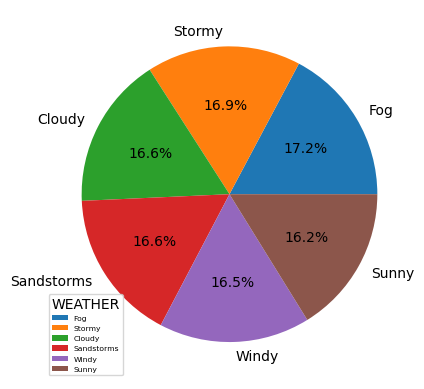

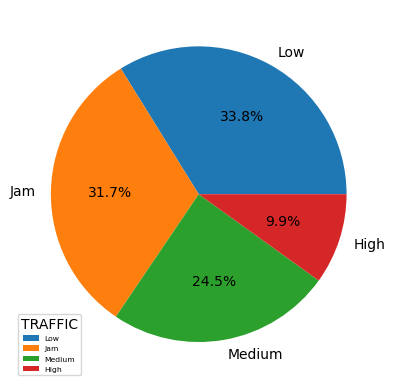

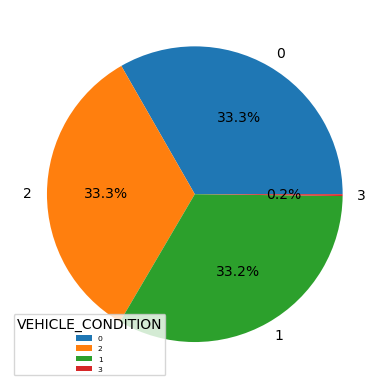

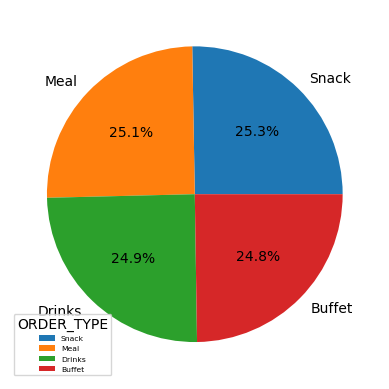

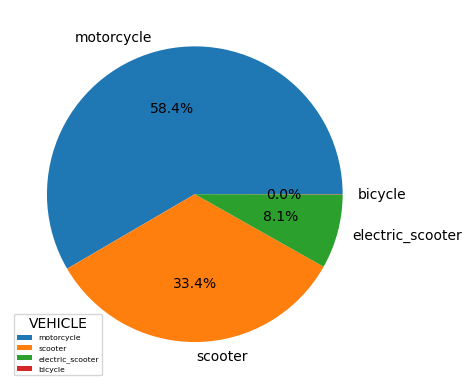

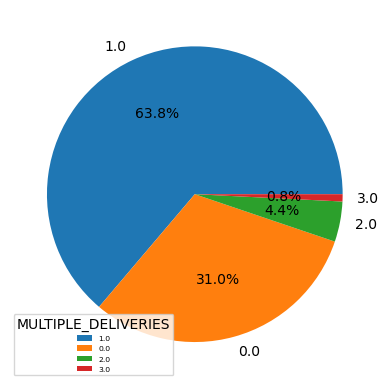

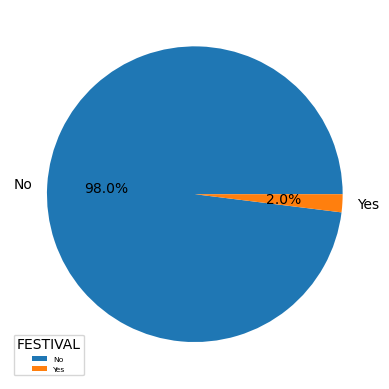

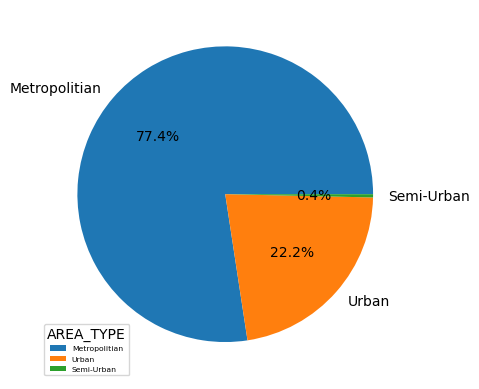

In [114]:
# Plot again the pie chart with categorical variables to see how NA'are replaced with mode

def pie_chart(dataframe):
    for column in dataframe:
        pie = dataframe[column].value_counts(dropna = False) # Include NA's in the 
        label = [entry for entry in pie.index]
        
        plt.pie(pie,labels = label, autopct = '%.1f%%')
        plt.legend(title = column.upper(), loc = "lower left", fontsize = 5.5)
        plt.show()
        
pie_chart(zomato_cats)

##### Comments on Pie-charts

##### The proportion of delivery orders is evenly distributed by different weather (around 16% each)
##### The  41.6% delivery orders are made under Jam and High traffic, whereas 33.8% of delivery orders are made under low traffic situations. 
##### More than half of the delivery orders are delivered by motorcycle (58.45%); the least-used delivery transportation is by bicycle.
##### Most deliveries do not involve multiple deliveries, as the multiple deliveries of 2 or 3 account for 5.2 % of the total number of deliveries. 
##### Most deliveries are delivered in Metropolitan or Urban Area (99.6%) and are non-festival orders.


##### 2.2 Delivery Times of All Orders: not accouting for each distinct riders

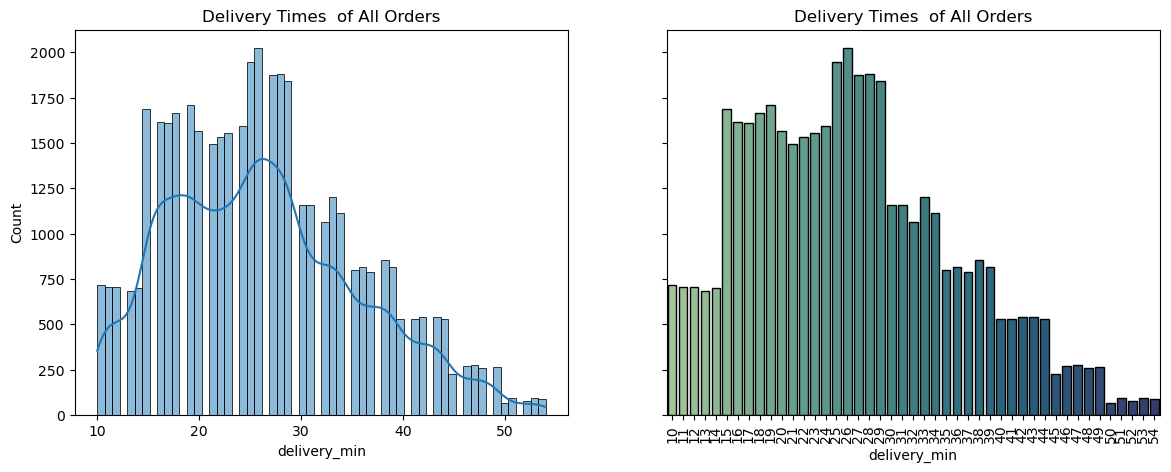

In [14]:
# What is the distribution of overall delivery time without controlling for distinct riders 
fig, (ax1,ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (14, 5), sharey = True)
sb.histplot(data = zomato, x = "delivery_min", ax  = ax1, kde = True)
ax1.set_title("Delivery Times  of All Orders")

sb.countplot(data = zomato, x= "delivery_min",  ax = ax2, palette = 'crest', edgecolor = 'k')
ax2.set_title("Delivery Times  of All Orders")

plt.xticks(rotation = 90);

##### The distribution of delivery time is slightly right-skewed, 
##### possibly normally distributed if extreme delivery times are removed as outliers.

<Axes: xlabel='delivery_min'>

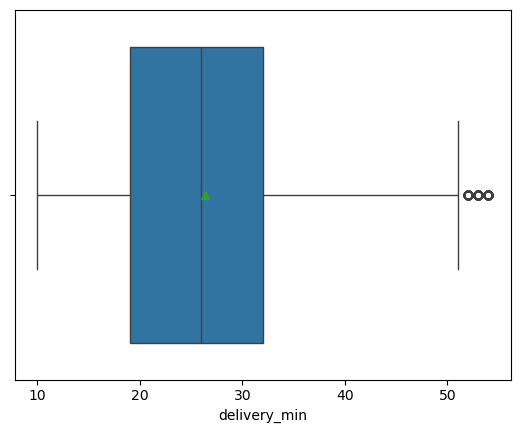

In [16]:
sb.boxplot(data = zomato, x = "delivery_min", showmeans = True)

In [18]:
zomato["delivery_min"].describe()

count    43241.000000
mean        26.330011
std          9.380164
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: delivery_min, dtype: float64

##### The average of order delivery time is about 26 minutes 
##### The fastest order delivery time of an order is 10 minutes
##### The latest order delivery time of an order is 54 minutes 

##### 2.3 Feature Variables and Target Variable Correlations

<Axes: >

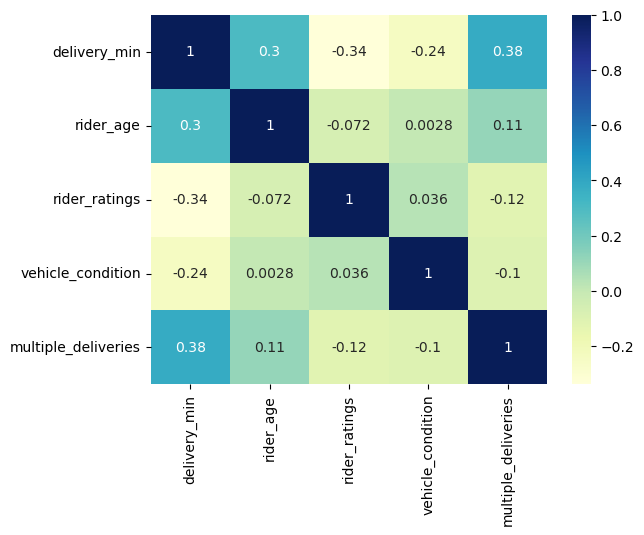

In [12]:
# Feature Variables and Target Variable Correlations
#zomato.columns

zomato_corr = zomato[['delivery_min', 'rider_age', 'rider_ratings', 'vehicle_condition', 'multiple_deliveries']]

sb.heatmap(zomato_corr.corr(), cmap = "YlGnBu",  annot = True)

#### No strong multicolinearity between feature variables

#### Delivery times has moderately positive linear relationship between riders' age and number of multiple deliveries and moderately negative linear relationship between vehicle condition and riders' ratings

In [ ]:
# Scattter Matrix 산점도 행렬 
#from pandas.plotting import scatter_matrix

#scatter_matrix(zomato_corr,  figsize = (10, 10), diagonal = 'kde')
#plt.show()

##### 2.4 Delivery time by weather, traffic, vehicle condtions, order type, vehicle types, multiple deliveries, festival, and area types.  


##### Weather and Traffic

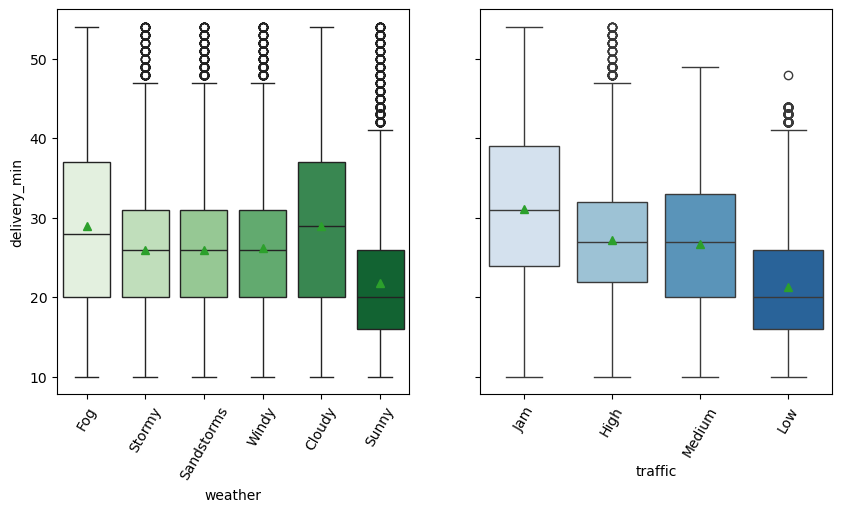

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (10, 5), sharey = True)

sb.boxplot(x = "weather", y = "delivery_min", ax= ax1, data = zomato, palette =  "Greens", showmeans = True)
sb.boxplot(x = "traffic", y = "delivery_min", ax= ax2, data = zomato, palette =  "Blues", showmeans = True)

for ax in [ax1, ax2]:
    for tick in ax.get_xticklabels():
        tick.set_rotation(60);

##### The average delivery time is lowest in sunny weather condition and highest in cloudy weather.  
##### The average delivery time is lowest in deliveries made under low traffic and highest under Jam traffic. 


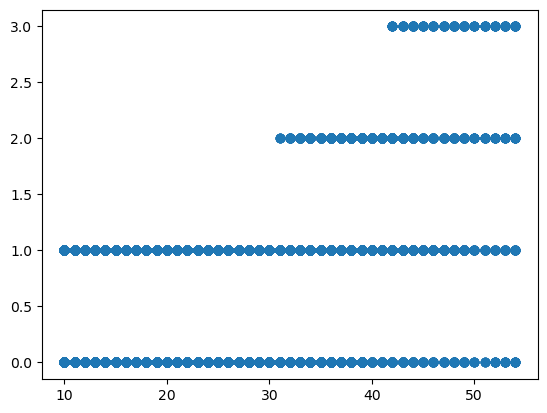

In [27]:
plt.scatter(x = zomato["delivery_min"], y = zomato["multiple_deliveries"])

##### Delivery time and Vehicles

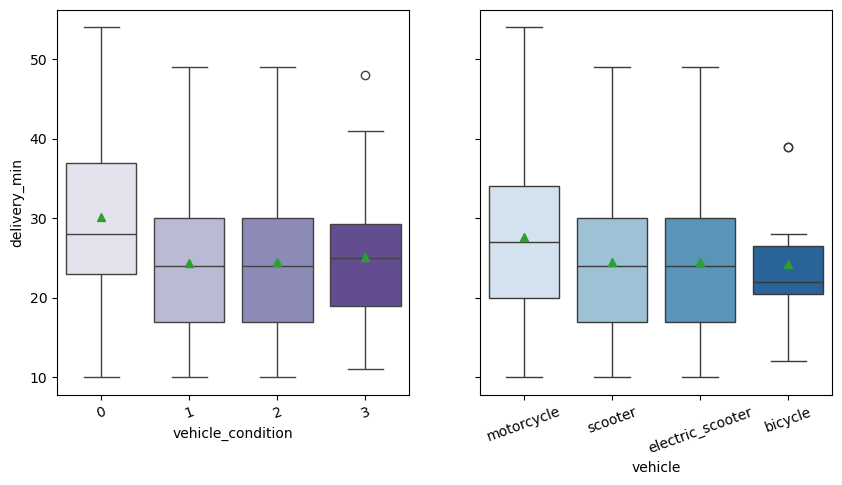

In [185]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (10, 5), sharey = True)

sb.boxplot(x = 'vehicle_condition', y = "delivery_min", ax= ax1, data = zomato, palette =  "Purples", showmeans = True)
sb.boxplot(x = "vehicle", y = "delivery_min", ax= ax2, data = zomato, palette =  "Blues", showmeans = True)

for ax in [ax1, ax2]:
    for tick in ax.get_xticklabels():
        tick.set_rotation(20);

##### The average delivery time is lowest with delivery vehicle condition 1 and highest with condition 0.  
##### The average delivery time is lowest for the deliveries by scooter and highest for the deliveries by motorcycle

##### Delivery time by order type and special occasion

<Axes: xlabel='festival', ylabel='delivery_min'>

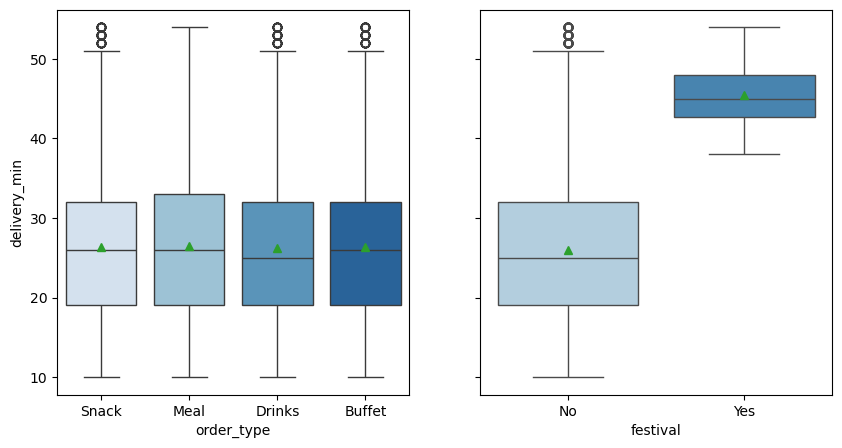

In [207]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (10, 5), sharey = True)
sb.boxplot(x = "order_type", y = "delivery_min", ax= ax1, data = zomato, palette =  "Blues", showmeans = True)
sb.boxplot(x = "festival", y = "delivery_min", ax= ax2, data = zomato, palette =  "Blues", showmeans = True)

##### There is no signifant difference between the average delivery times of diffrent order types.
##### However, the average delivery times seem to be significantly different depending on whether the order is for the festival or not.

##### Delivery time by area type and multiple deliveries 

<Axes: xlabel='multiple_deliveries', ylabel='delivery_min'>

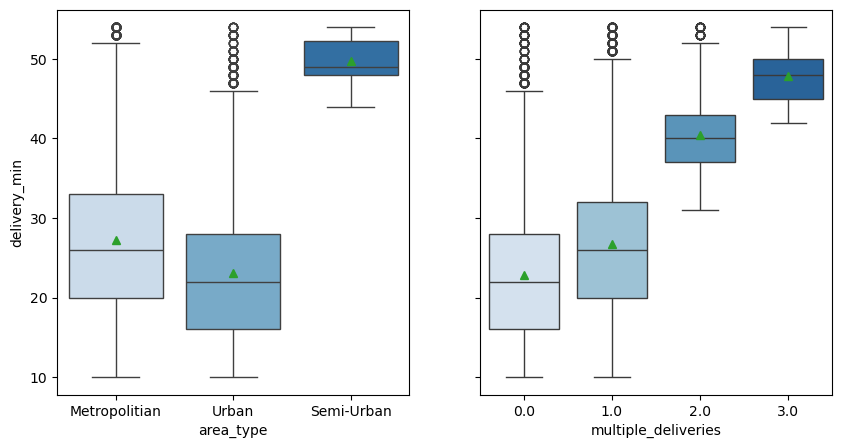

In [187]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (10, 5), sharey = True)

sb.boxplot(x = "area_type", y = "delivery_min", ax= ax1, data = zomato, palette =  "Blues",showmeans = True)
sb.boxplot(x = "multiple_deliveries", y = "delivery_min", ax= ax2, data = zomato, palette =  "Blues",showmeans = True)

##### The average delivery times of metropolitan and urban area do not seem to be significantly different 
##### but the average delivery time of semi-urban is higher than one in metropolitan and urban area.

##### The average delivery times are higher as the number of multiple deliveries increases.

#### Delivery Time and Feature Variables Boxplots Summary 

In [ ]:
#### 

##### 2.5 Average Delivery Time 

#### By order date: Time Series Plot of Average Delivery Time

##### Avergage delivery time taken in minutes by each date

In [28]:
date_times= zomato.groupby(sorted(zomato["order_date"]))["delivery_min"].mean()
date_times

2022-02-11    26.290635
2022-02-12    25.942961
2022-02-13    26.716172
2022-02-14    26.129630
2022-02-15    26.313483
2022-02-16    26.788820
2022-02-17    26.745516
2022-02-18    26.856070
2022-03-01    26.424696
2022-03-02    26.587683
2022-03-03    26.527453
2022-03-04    25.958874
2022-03-05    26.557866
2022-03-06    26.314225
2022-03-07    26.415285
2022-03-08    26.170330
2022-03-09    25.698284
2022-03-10    26.520990
2022-03-11    26.207024
2022-03-12    26.644951
2022-03-13    26.204668
2022-03-14    26.282302
2022-03-15    26.427812
2022-03-16    25.796394
2022-03-17    26.765799
2022-03-18    26.550976
2022-03-19    26.534247
2022-03-20    26.376609
2022-03-21    25.646575
2022-03-23    26.252203
2022-03-24    25.908676
2022-03-25    26.135722
2022-03-26    26.455605
2022-03-27    26.337676
2022-03-28    26.860315
2022-03-29    26.993464
2022-03-30    26.261270
2022-03-31    26.369281
2022-04-01    26.620183
2022-04-02    25.724839
2022-04-03    26.228444
2022-04-04    25

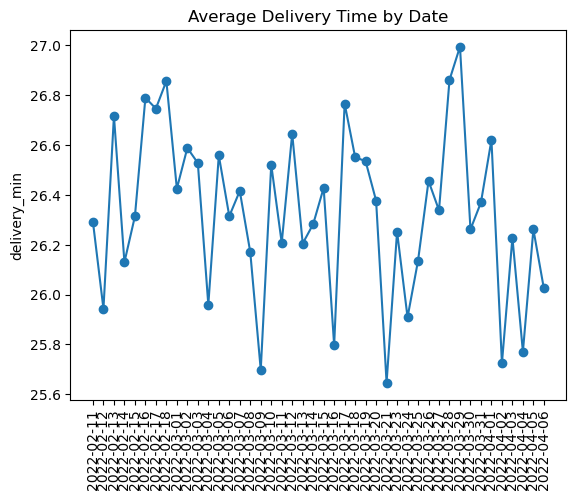

In [34]:
plt.scatter(x = date_times.index, y = date_times)
sb.lineplot(data = date_times)
plt.title("Average Delivery Time by Date")
plt.xticks(rotation = 90);

##### Time Series Plot 

##### The average delivery time is lowest (25.64) on March 21st and latest on March 29th.
##### There is about a 1-minute difference in average delivery times on the following dates: 
##### 3/9-3/10 , 3/16-17


#### By Month 

2    26.472733
3    26.337882
4    26.128659
Name: delivery_min, dtype: float64


Text(0.5, 1.0, 'Average Delivery Time by Month')

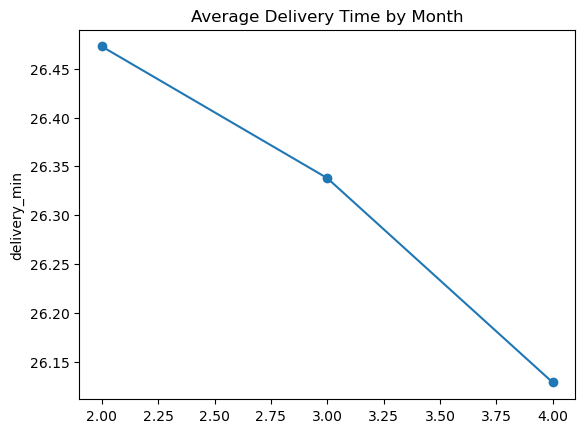

In [92]:
date_month = zomato.groupby(sorted(zomato["month"]))["delivery_min"].mean()
print(date_month)
plt.scatter(x = date_month.index, y = date_month)
sb.lineplot(data = date_month)
plt.title("Average Delivery Time by Month")

#### By Distinct Riders 


Text(0.5, 1.0, 'Average Delivery Time of Riders')

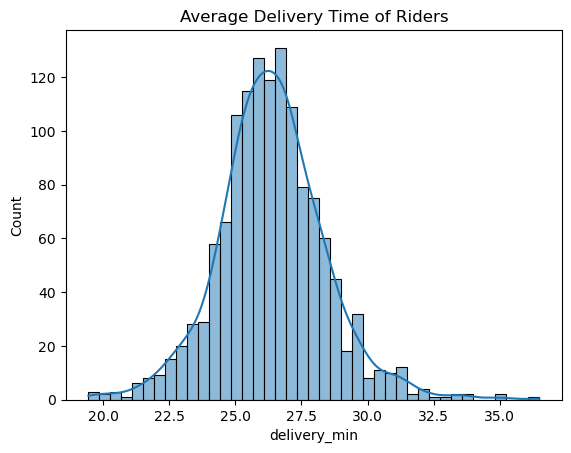

In [14]:
# Distribution of Average delivery time of the distinct riders
time_riders = zomato.groupby(zomato["rider_id"])["delivery_min"].mean()
sb.histplot(time_riders, kde  = True)
plt.title("Average Delivery Time of Riders")

In [109]:
time_riders.describe()

count    1320.000000
mean       26.389062
std         2.017831
min        19.444444
25%        25.198780
50%        26.306250
75%        27.525886
max        36.500000
Name: delivery_min, dtype: float64

##### The mean of the distinct riders' average delivery time is about 26 minutes 
##### The fastest average delivery time of a rider is 18 minutes and 45 seconds 
##### The latest average delivery time of a rider is 35 minutes 

#### 3. Delivery Person Ratings
- To evaluate the rider's delivery performance by delivery person's ratings, we need to find
    - Overall order ratings  
    - Average delivery ratings of each distinct rider
    - Low ratings and good ratings  

##### 3.1. Distribution of all rider ratings 

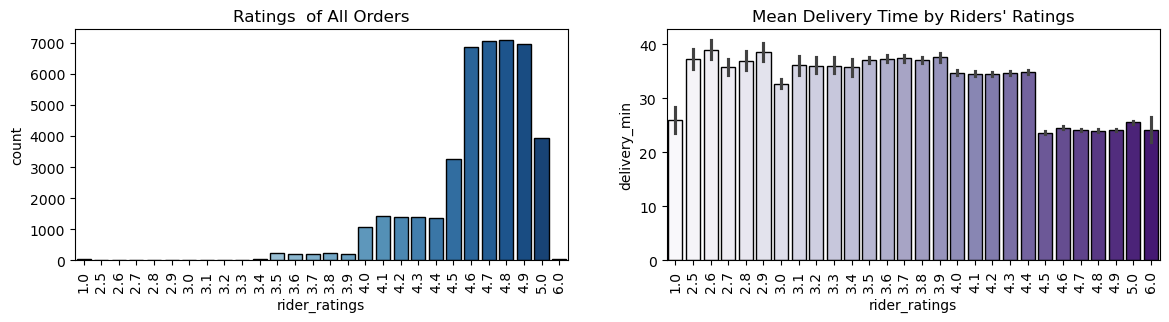

In [16]:
# What is the distribution of all rider ratings 
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (14, 3))

sb.countplot(x = "rider_ratings", data = zomato, ax = ax1, palette = "Blues", edgecolor = "k")
ax1.set_title("Ratings  of All Orders")

sb.barplot(data = zomato, x = "rider_ratings", y = "delivery_min", estimator = "mean", 
          ax = ax2, palette = "Purples", edgecolor = "k")
ax2.set_title("Mean Delivery Time by Riders' Ratings")
for ax in [ax1, ax2]:
    for tick in ax.get_xticklabels():
        tick.set_rotation(90);

In [10]:
zomato["rider_ratings"].describe()

count    43241.000000
mean         4.633723
std          0.333051
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: rider_ratings, dtype: float64

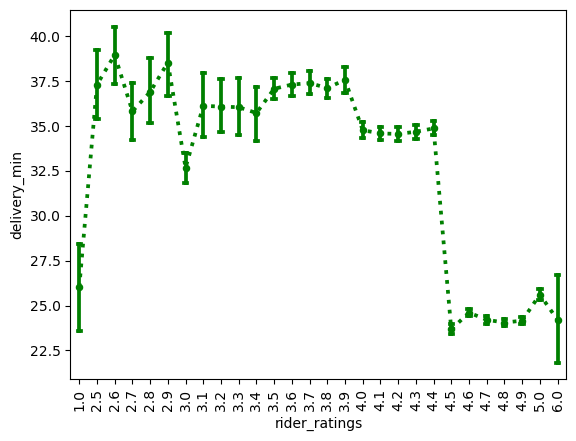

In [98]:
sb.pointplot(data = zomato, x = 'rider_ratings', y = 'delivery_min', capsize = .2,
              linestyles = ':', markers = '.', color = 'green')
plt.xticks(rotation = 90);

##### Riders with 6-rating

In [123]:
zomato[zomato["rider_ratings"] == 6]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
3391,0x46d,BANGRES05DEL01,50.0,6.0,-12.970324,-77.645748,13.010324,77.685748,2022-03-13,NaN,...,Meal,electric_scooter,0.0,No,Urban,25,-153722867280912928,3,NaN,0
4458,0x493,HYDRES17DEL01,50.0,6.0,-17.451976,-78.385883,17.561976,78.495883,2022-04-04,NaN,...,Snack,bicycle,0.0,No,Metropolitian,27,-153722867280912928,4,NaN,0
4894,0x4f2,JAPRES08DEL01,50.0,6.0,-26.910262,-75.783013,27.020262,75.893013,2022-03-18,NaN,...,Drinks,scooter,1.0,No,Metropolitian,20,-153722867280912928,3,NaN,0
5078,0x430,BANGRES19DEL01,50.0,6.0,12.914264,77.678400,13.024264,77.788400,2022-04-06,NaN,...,Meal,electric_scooter,1.0,No,Metropolitian,18,-153722867280912928,4,NaN,0
5350,0xbef1,AGRRES13DEL02,50.0,6.0,-27.159795,-78.042990,27.209795,78.092990,2022-02-13,NaN,...,Drinks,scooter,1.0,No,Metropolitian,20,-153722867280912928,2,NaN,0
6060,0x427,JAPRES06DEL02,50.0,6.0,26.911927,75.797282,27.041927,75.927282,2022-04-02,NaN,...,Meal,electric_scooter,0.0,No,Urban,20,-153722867280912928,4,NaN,0
7278,0xd42,VADRES09DEL01,50.0,6.0,0.000000,0.000000,0.010000,0.010000,2022-03-21,NaN,...,Meal,bicycle,1.0,No,Metropolitian,22,-153722867280912928,3,NaN,0
9011,0x3f0,BANGRES010DEL01,50.0,6.0,12.933298,77.614293,13.003298,77.684293,2022-03-12,NaN,...,Drinks,scooter,1.0,No,Urban,17,-153722867280912928,3,NaN,0
9045,0x3ef,RANCHIRES13DEL01,50.0,6.0,-23.374989,-85.335486,23.444989,85.405486,2022-03-20,NaN,...,Snack,bicycle,1.0,No,Metropolitian,32,-153722867280912928,3,NaN,0
9587,0x5b0,MYSRES04DEL01,50.0,6.0,12.308500,76.665808,12.418500,76.775808,2022-03-18,NaN,...,Snack,electric_scooter,1.0,No,Metropolitian,35,-153722867280912928,3,NaN,0


##### Riders with 1-rating

In [370]:
zomato[zomato["rider_ratings"] == 1]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
2251,0x564,JAPRES15DEL03,15.0,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaN,...,Meal,motorcycle,0.0,No,Urban,15,-153722867280912928,3,NaN,0
2739,0xcd0,INDORES010DEL03,15.0,1.0,22.750040,75.902847,22.810040,75.962847,2022-04-03,NaN,...,Snack,scooter,1.0,No,Metropolitian,29,-153722867280912928,4,NaN,0
2784,0x91a,SURRES17DEL03,15.0,1.0,21.149569,72.772697,21.209569,72.832697,2022-03-21,NaN,...,Buffet,bicycle,1.0,No,Metropolitian,20,-153722867280912928,3,NaN,0
5590,0x474,CHENRES15DEL03,15.0,1.0,13.026286,80.275235,13.056286,80.305235,2022-03-11,NaN,...,Drinks,bicycle,1.0,No,Metropolitian,25,-153722867280912928,3,NaN,0
8684,0x73f,BANGRES05DEL01,15.0,1.0,12.970324,77.645748,13.080324,77.755748,2022-03-25,NaN,...,Buffet,motorcycle,2.0,No,Metropolitian,34,-153722867280912928,3,NaN,0
10354,0x1b49,MUMRES14DEL02,15.0,1.0,19.181300,72.836191,19.231300,72.886191,2022-03-30,NaN,...,Buffet,motorcycle,1.0,No,Metropolitian,39,-153722867280912928,3,NaN,0
10573,0x40b,SURRES12DEL01,15.0,1.0,-21.183434,-72.814492,21.193434,72.824492,2022-03-05,NaN,...,Meal,scooter,1.0,No,Urban,27,-153722867280912928,3,NaN,0
11486,0x523,INDORES03DEL02,15.0,1.0,22.751857,75.866699,22.801857,75.916699,2022-03-24,NaN,...,Buffet,bicycle,0.0,No,Metropolitian,28,-153722867280912928,3,NaN,0
14376,0x18b0,RANCHIRES02DEL01,15.0,1.0,0.000000,0.000000,0.070000,0.070000,2022-03-16,NaN,...,Meal,bicycle,1.0,No,Metropolitian,21,-153722867280912928,3,NaN,0
15145,0x550,CHENRES08DEL02,15.0,1.0,13.022394,80.242439,13.072394,80.292439,2022-03-11,NaN,...,Snack,bicycle,0.0,No,Metropolitian,17,-153722867280912928,3,NaN,0


##### We can see the age diffrence between the rider group with 1-rating and one with 6-rating. 
##### The ages of the riders with 1-rating are all 15's, whereas the ages of the riders with 6 ratings are all 50's. 

##### We can visualize the relationship between ratings and a rider's age. 

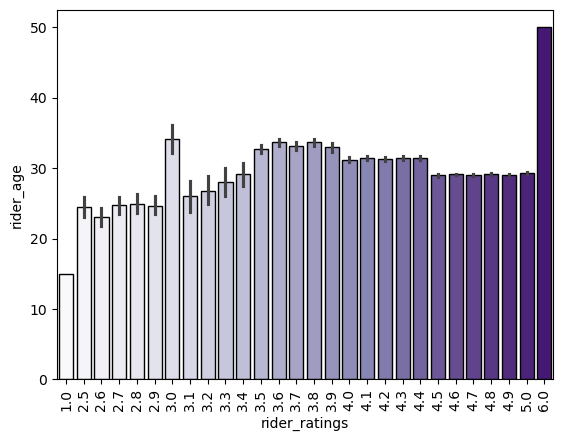

In [150]:
sb.barplot(data = zomato, x = "rider_ratings", y = "rider_age", estimator = "mean", palette = "Purples", edgecolor = "k")
plt.xticks(rotation =  90);

##### The most of the riders age are between 20's or 30's with ratings ranges from 2.5 to 5. 
##### Only the riders in age 10's are rated 1, whereas the riders in age 50's are rated over 5 which exceeds the normal scale of rating.

##### 3.2 Good ratings vs Bad Ratings of Riders
- Based on the distribution plot of the ratings, the number of ratings less than or equal to 3
is relatively smaller than the one greater than or equal to 4, which accounts for the majority of riders' ratings.

- We define whether the ratings are good or bad by rating score criteria such as
    - Bad ratings: ratings less or equal to 3
    - Good ratings: ratings equal to 5.

##### What are the orders with less than 3 score ratings?

In [25]:
ratings_3 = zomato[(zomato["rider_ratings"] <= 3.0)] 
ratings_3[zomato_cats.columns]

print("There are", len(ratings_3), "ratings less than or equal to 3.")

There are 140 ratings less than or equal to 3.


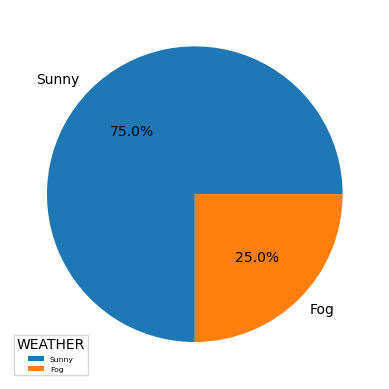

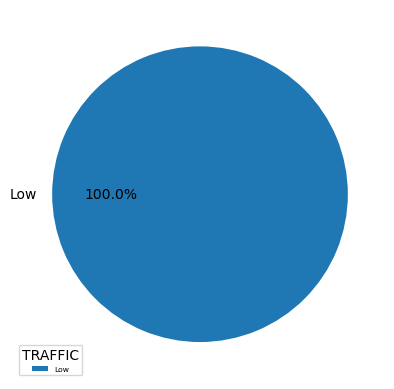

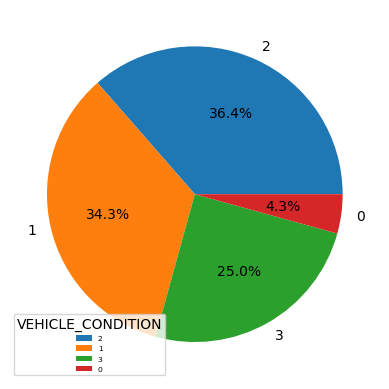

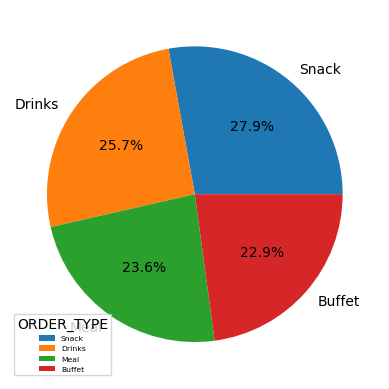

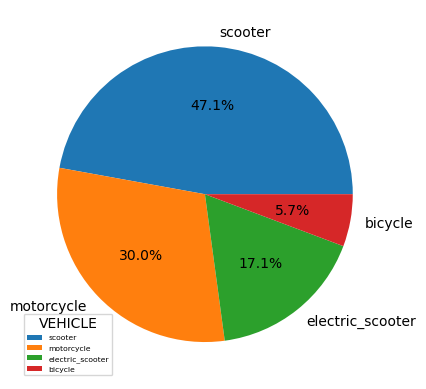

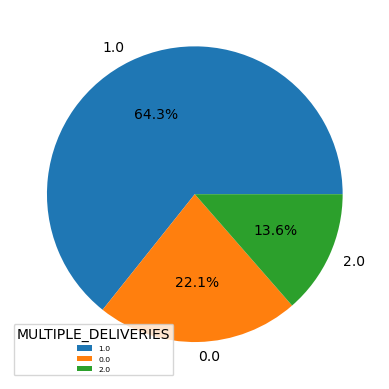

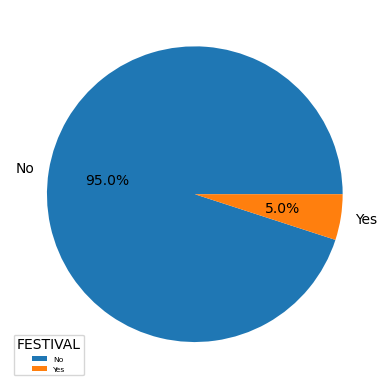

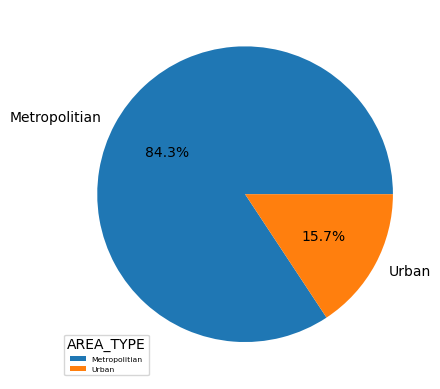

In [67]:
pie_chart(ratings_3[zomato_cats.columns])

##### The ratings less than or equal 3 are made during low traffic mostly on sunny and partly on foggy days.

In [251]:
# Average delivery time of all ratings less than or equal to 3
ratings_3["delivery_min"].describe()

count    140.000000
mean      34.421429
std        6.991329
min       13.000000
25%       31.000000
50%       35.000000
75%       39.000000
max       44.000000
Name: delivery_min, dtype: float64

##### Number of ratings less than or equal to 3 by each date

In [77]:
# Count the number of orders by each date
date_orders = zomato.groupby(sorted(zomato["order_date"]))["order_id"].count()
 # "date is in yyyy-mm-dd"

#sb.scatterplot(date_orders)
date_order = list(date_orders.index)
# date_order # Number of orders by each date

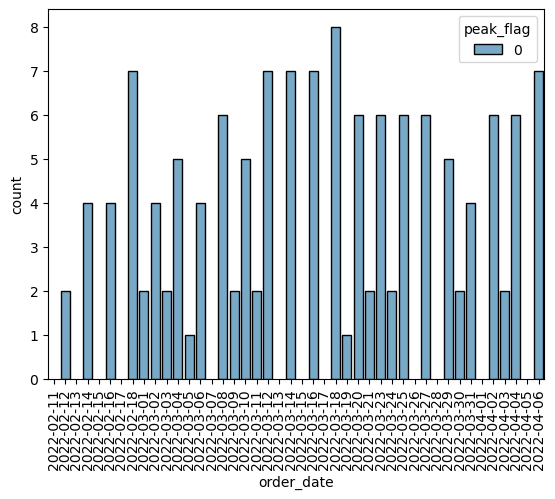

In [79]:
# Number of bad ratings by each date 
sb.countplot(x = "order_date", data = ratings_3, palette = "Blues",  order = date_order, hue = "peak_flag", edgecolor = "k")
plt.xticks(rotation= 90);

##### The number of ratings less than or equal to 3 is highest (8 ratings) on March 18th 

##### The ratings less than or equal to 3 are made during  non-peak times. 

##### What are the orders with 5-score ratings?


In [27]:
ratings_5 = zomato[(zomato["rider_ratings"] == 5.0)]
ratings_5[zomato_cats.columns]
print("There are", len(ratings_5), "ratings equal to 5.")

There are 3946 ratings equal to 5.


In [100]:
ratings_5["delivery_min"].describe()

count    3946.000000
mean       25.609225
std         9.269346
min        10.000000
25%        18.000000
50%        25.000000
75%        31.000000
max        54.000000
Name: delivery_min, dtype: float64

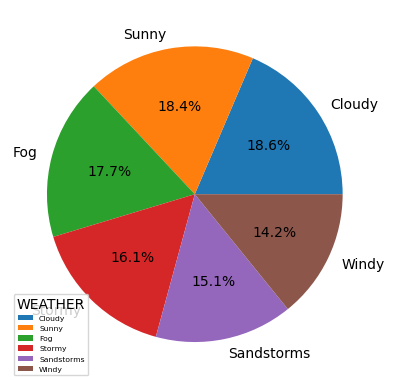

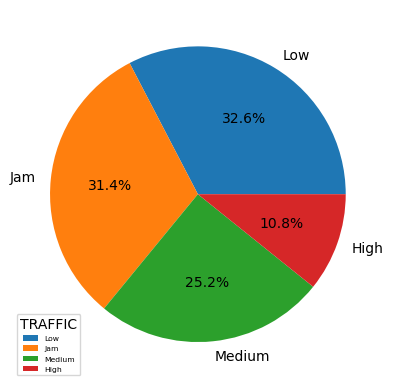

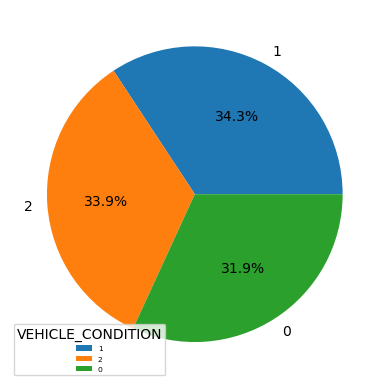

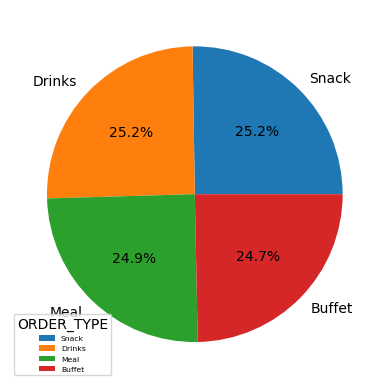

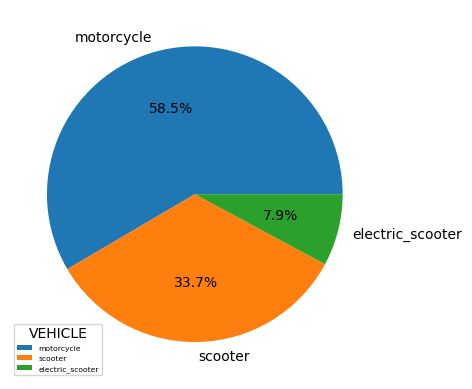

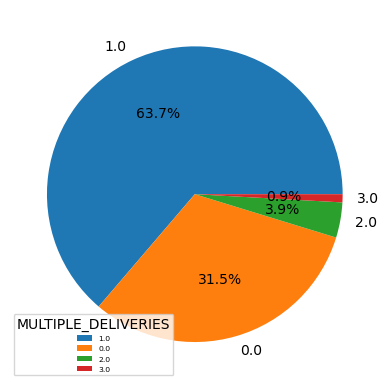

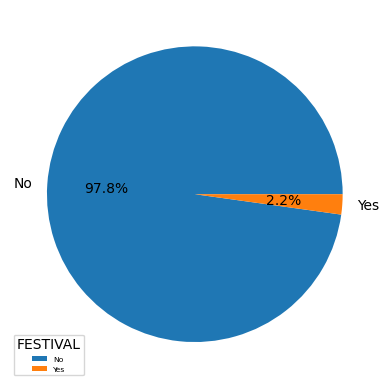

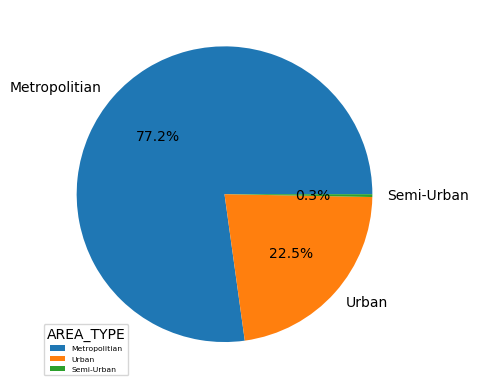

In [89]:
pie_chart(ratings_5[zomato_cats.columns])

##### The pie charts of the categorical variables of 5-score-rating-only data show simliar distributions category as the pie-charts of the whole dataset. 

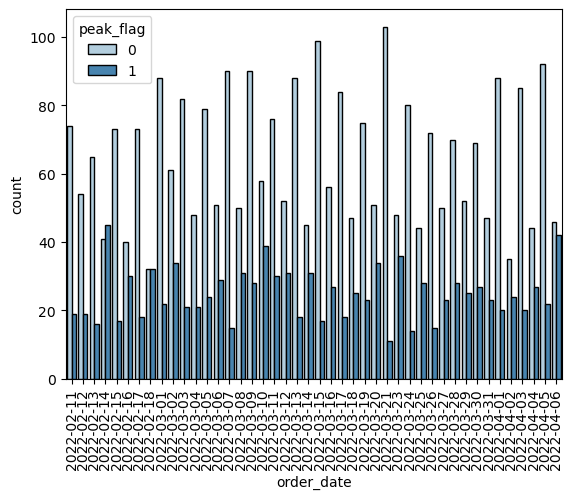

In [94]:
# Number of good ratings by each date 
sb.countplot(x = "order_date", data = ratings_5, palette = "Blues",  order = date_order, hue = "peak_flag", edgecolor = "k")
plt.xticks(rotation= 90);

##### Compare the delivery time distribution of the two groups 

- Ratings_3 (in blue)
- Ratings_5 (in yellow)

<Axes: xlabel='delivery_min', ylabel='Density'>

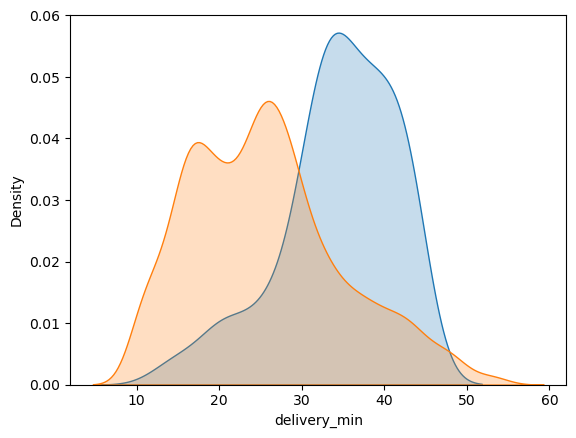

In [31]:
#sb.boxplot(x = "delivery_min", data = ratings_3)
sb.kdeplot(x = "delivery_min", data = ratings_3, fill = True)
sb.kdeplot(x = "delivery_min", data = ratings_5, fill = True)

#### The average delivery time less than or equal to 3 is about 34 minutes, whereas the average delivery time equal to 5 is about 25 minutes which about 9 minute average time difference. 

#### The delivery ratings less than or equal to 3 were made on orders when the weather is mostly sunny 
#### in metropolitan and urban areas delivered using scooters under low traffic situations. 
#### We can assume that the longer deliveries (more than 30-minute) made on sunny, low-traffic days are rated more harshly than the shorter deliveries made under same condition (suuny, low).

#### We can check the assumption by taking a random sample of the same size as ratings 3 group from the group of ratings equal to 5 to compare the weather and traffic conditions. 

### Orders made on sunny, low-traffic days
- Compare delivery times of bad ratings and good ratings on sunny, low-traffic days.
-  Bad ratings: ratings less or equal to 3
- Good ratings: ratings equal to 5

In [12]:
sunny_traffic_low = zomato[(zomato["weather"] ==  "Sunny") & (zomato["traffic"] == "Low")]
sunny_traffic_low

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
29,0x4bda,HYDRES17DEL02,35.0,5.0,17.451976,78.385883,17.471976,78.405883,2022-04-01,1900-01-01 09:45:00,...,Snack,scooter,1.0,No,Urban,11,10,4,9.0,0
46,0xddc5,AGRRES12DEL03,39.0,4.6,27.165108,78.015053,27.255108,78.105053,2022-02-14,1900-01-01 22:45:00,...,Snack,motorcycle,1.0,No,Metropolitian,27,-153722867280912928,2,22.0,0
85,0x97e3,MYSRES16DEL02,29.0,5.0,12.316967,76.603067,12.366967,76.653067,2022-04-01,1900-01-01 22:20:00,...,Drinks,motorcycle,0.0,No,Metropolitian,18,5,4,22.0,0
99,0x1e42,SURRES08DEL01,25.0,4.6,21.173343,72.792731,21.283343,72.902731,2022-03-10,1900-01-01 23:20:00,...,Drinks,motorcycle,1.0,No,Metropolitian,23,15,3,23.0,0
101,0x24ac,SURRES05DEL02,27.0,4.6,21.175104,72.804342,21.255104,72.884342,2022-03-14,1900-01-01 23:45:00,...,Snack,motorcycle,1.0,No,Metropolitian,24,5,3,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43096,0xac7b,COIMBRES17DEL01,21.0,5.0,11.026117,76.944652,11.096117,77.014652,2022-03-20,1900-01-01 22:45:00,...,Drinks,motorcycle,1.0,No,Metropolitian,25,10,3,22.0,0
43132,0x6453,PUNERES07DEL02,31.0,4.7,18.546947,73.900626,18.566947,73.920626,2022-03-30,1900-01-01 09:45:00,...,Snack,scooter,1.0,No,Urban,16,-153722867280912928,3,9.0,0
43177,0x811b,SURRES19DEL01,33.0,4.7,21.149669,72.772629,21.159669,72.782629,2022-03-03,1900-01-01 10:20:00,...,Buffet,motorcycle,1.0,No,Metropolitian,26,5,3,10.0,0
43184,0x3781,JAPRES13DEL03,35.0,4.9,26.846156,75.802300,26.876156,75.832300,2022-03-09,1900-01-01 23:50:00,...,Snack,scooter,0.0,No,Urban,17,-153722867280912928,3,23.0,0


In [20]:
sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0]["rider_ratings"].mean()

2.7123809523809523

In [50]:
sunny_traffic_low["peak_flag"].value_counts()

peak_flag
0    2327
Name: count, dtype: int64

##### 2347 deliveries on sunny and low-traffic days are made during non-peak time.

In [261]:
sunny_traffc_low["delivery_min"].corr(sunny_traffc_low["rider_ratings"])

-0.6970832120081384

##### The correlation of delivery time and riders' ratings of deliveries on sunny and low-traffic days shows that they are in strongly negative linear relationship.
#### The longer the delivery time, the lower the rider ratings. 

In [ ]:
# Distribution of bad ratings on sunny, low traffic conditions

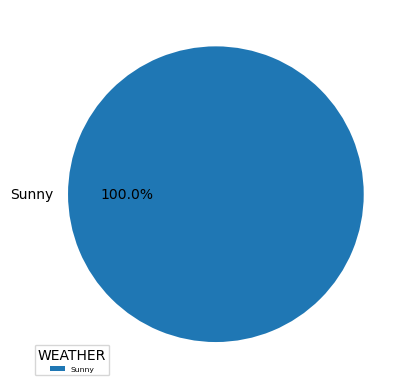

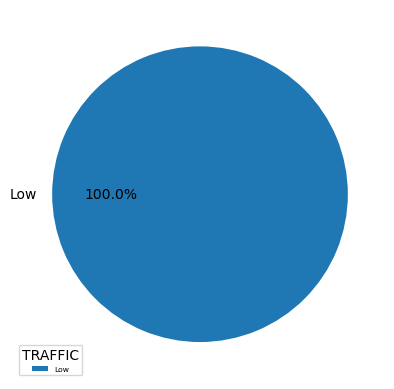

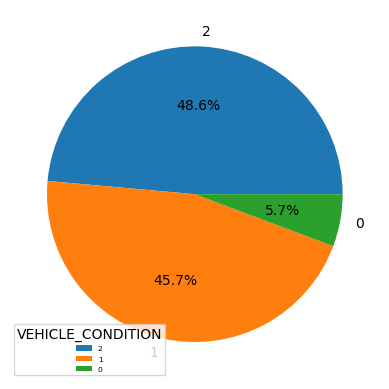

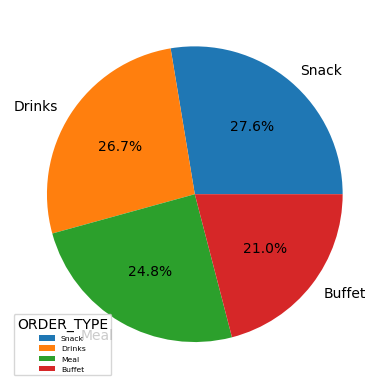

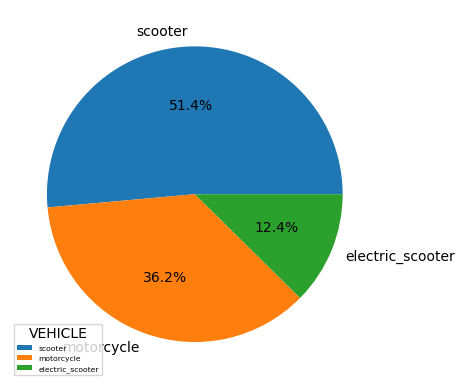

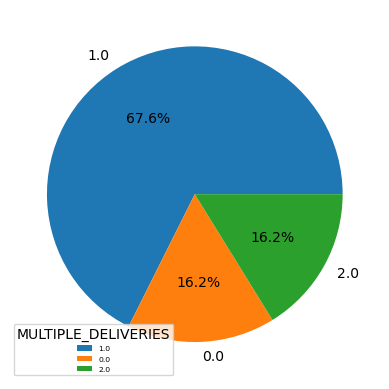

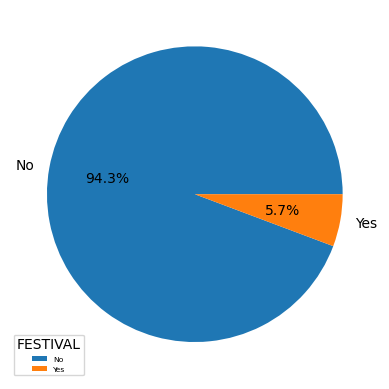

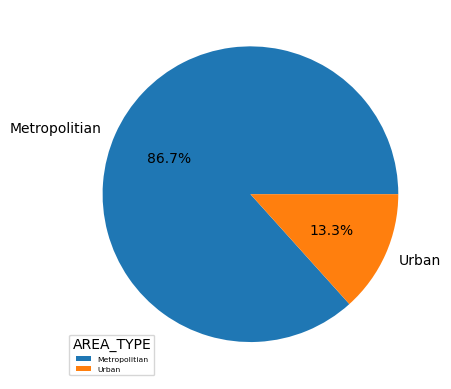

In [116]:
pie_chart(sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0][zomato_cats.columns])

In [ ]:
# Distribution of bad ratings by age

Text(0.5, 1.0, "Distribution of Riders' Age with Bad Ratings")

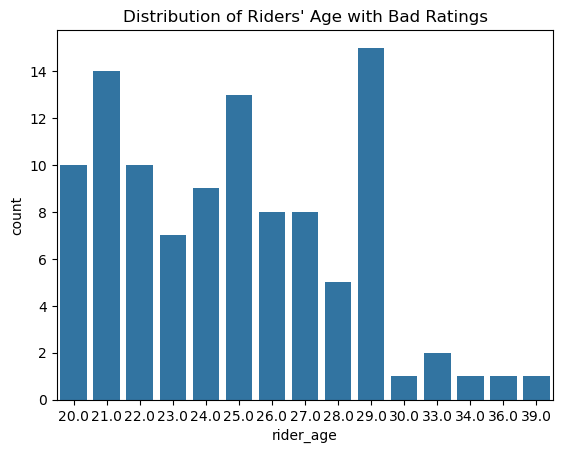

In [57]:
sb.countplot(x = "rider_age", data = sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0])
plt.title("Distribution of Riders' Age with Bad Ratings")

##### Most of the riders' age with ratings less than or equal to 3 range from age 20 to 29; no riders with age 10's or age 50's are shown.

In [345]:
sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0]["hour"].value_counts()

hour
23.0    52
22.0    47
Name: count, dtype: int64

##### The bad ratings of deliveries on sunny and low-traffic days are made from 22:00pm to 23:00pm 

##### Visualize delivery time vs. rider ratings on sunny, low-traffic days

Text(0, 0.5, "Rider's Rating")

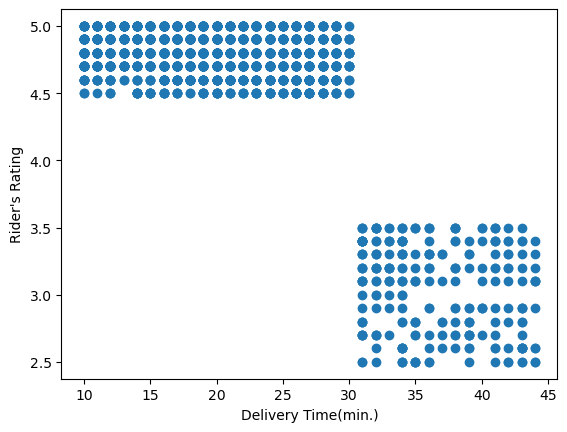

In [224]:
plt.scatter(x = zomato[(zomato["weather"] ==  "Sunny") & (zomato["traffic"] == "Low")]["delivery_min"],
            y = zomato[(zomato["weather"] ==  "Sunny") & (zomato["traffic"] == "Low")]["rider_ratings"])

plt.xlabel("Delivery Time(min.)")
plt.ylabel("Rider's Rating")

<Axes: xlabel='delivery_min', ylabel='rider_ratings'>

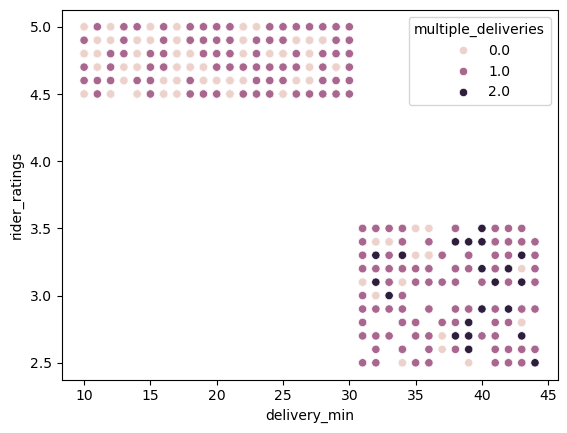

In [441]:
sb.scatterplot(x = "delivery_min", y = "rider_ratings", data = sunny_traffic_low, hue = "multiple_deliveries")

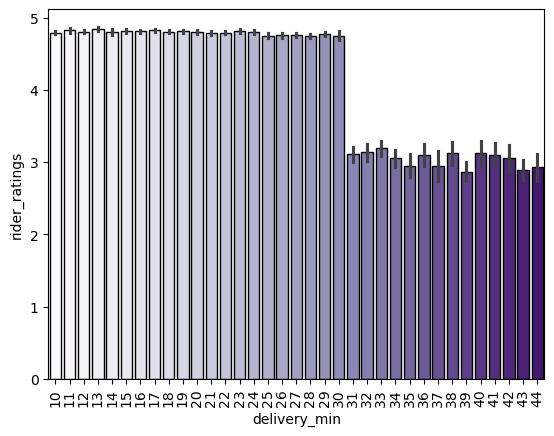

In [360]:
sb.barplot(data = sunny_traffic_low, y = "rider_ratings", x = "delivery_min", estimator = "mean", palette = "Purples", edgecolor = "k")
plt.xticks(rotation = 90);

##### The rider ratings drop from "higher than or equal to 4.5" to "lower than or equal to 3.5 but not equal to 1" when delivery times start to exceed 30 minutes. 

##### Visualize delivery time and rider ratings of different weather and traffic conditions, especially the conditions that are expected to have longer delivery times based on the pie-chars such as: 

- Fog and Low Traffic (To compare with Sunny, Low Traffic)
- Sunny and Jam Traffc 
- Fog  and Jam Traffic

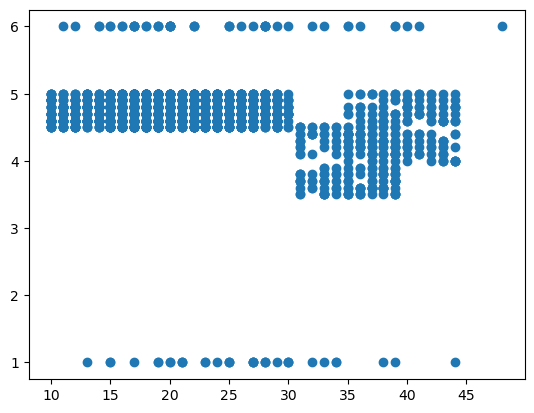

In [227]:
plt.scatter(x = zomato[(zomato["weather"] ==  "Fog") & (zomato["traffic"] == "Low")]["delivery_min"],
            y = zomato[(zomato["weather"] ==  "Fog") & (zomato["traffic"] == "Low")]["rider_ratings"])

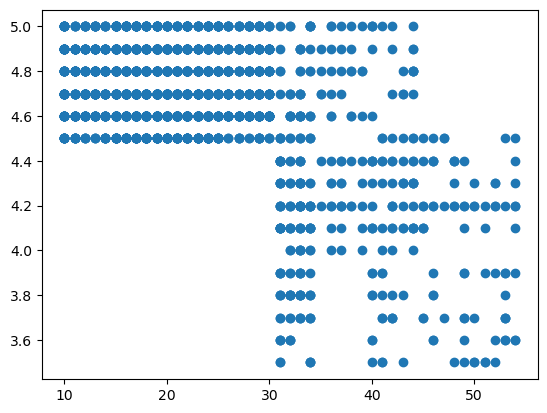

In [219]:
plt.scatter(x = zomato[(zomato["weather"] ==  "Sunny") & (zomato["traffic"] == "Jam")]["delivery_min"],
            y = zomato[(zomato["weather"] ==  "Sunny") & (zomato["traffic"] == "Jam")]["rider_ratings"])

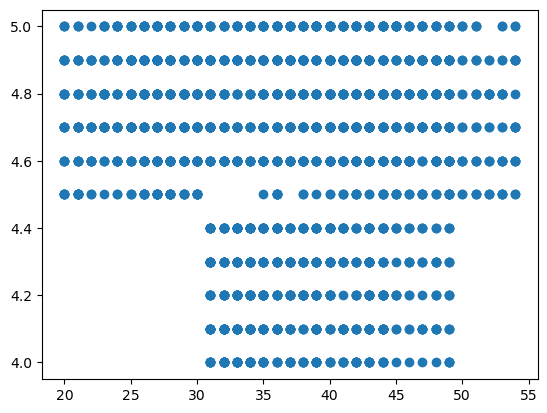

In [241]:
plt.scatter(x = zomato[(zomato["weather"] ==  "Fog") & (zomato["traffic"] == "Jam")]["delivery_min"],
            y = zomato[(zomato["weather"] ==  "Fog") & (zomato["traffic"] == "Jam")]["rider_ratings"])

##### Delivery time by groups: The ratings seem to decrease when the delivery time exceeds 30 minutes for all conditions: 

- Fog and Low Traffic (To compare with Sunny, Low Traffic)
- Sunny and Jam Traffc 
- Fog  and Jam Traffic

##### On sunny days with low traffic, the longer deliveries are rated more harshly than the shorter deliveries 
##### On sunny days with low traffic, delivery time and ratings have a negative linear relationship (-0.69)
##### A 30-minute time frame can be seen as a borderline for whether riders receive good or bad reviews. 

##### Delivery time: Sunny and Low Traffc: one with all low ratings

<Axes: xlabel='delivery_min', ylabel='Count'>

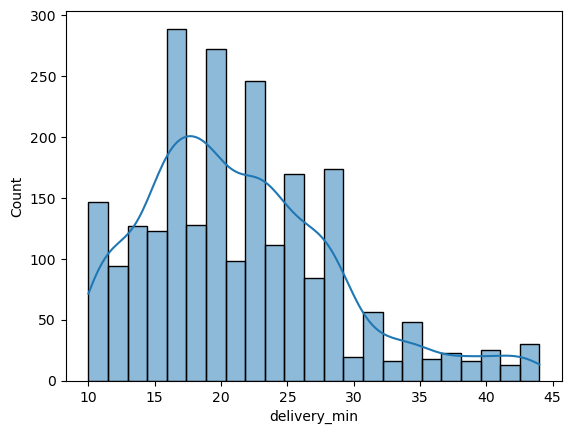

In [159]:
sb.histplot(sunny_traffic_low["delivery_min"], kde = True)

##### The delivery times of sunny, low-traffic days are left-skewed with wih heavy tail of delivery minutes startng from 30-minute.

In [337]:
sunny_traffic_low["hour"].value_counts()

hour
22.0    644
23.0    639
10.0    316
8.0     281
9.0     278
Name: count, dtype: int64

In [150]:
# Average delivery time of sunny weather in low traffic
sunny_traffic_low["delivery_min"].mean()

21.44563816072196

In [70]:
# Average delivery time of bad ratings <= 3.0  of sunny weather in low traffic
sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0]["delivery_min"].describe()

count    105.000000
mean      37.219048
std        4.185554
min       31.000000
25%       34.000000
50%       37.000000
75%       41.000000
max       44.000000
Name: delivery_min, dtype: float64

In [389]:
len(sunny_traffic_low[sunny_traffic_low["delivery_min"] >= 30])

264

In [72]:
# Average delivery time of deliveries with less than 30 minutes of sunny weather in low traffic
sunny_traffic_low[sunny_traffic_low["rider_ratings"]  ==  5.0]["delivery_min"].describe()

count    311.000000
mean      18.977492
std        5.039471
min       10.000000
25%       15.000000
50%       19.000000
75%       23.000000
max       30.000000
Name: delivery_min, dtype: float64

In [126]:
# Average delivery time difference between bad ratings and good ratings in sunny, low traffic conditions
sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0]["delivery_min"].mean() - sunny_traffic_low[sunny_traffic_low["rider_ratings"]  ==  5.0]["delivery_min"].mean()

18.24155565763283

In [85]:
round(sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0]["delivery_min"].mean()/
      sunny_traffic_low[sunny_traffic_low["rider_ratings"]  ==  5.0]["delivery_min"].mean(),1)

2.0

##### The average delivery time of bad ratings, about 37 minutes, and good ratings in sunny, low traffic conditions, about 18 minutes, differs by 18.24 minutes; the average delivery time of bad ratings in sunny, low traffic conditions is about twice longer than the one of good ratings.  


In [385]:
len(sunny_traffic_low[sunny_traffic_low["delivery_min"] < 30])

2063

In [310]:
# Number of ratings less or than equal to 3 in sunny, low traffic dataset
len(sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0])

105

In [330]:
print("About", round(len(sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0])
                     /len(sunny_traffic_low),2)*100,
      "% of the sunny, low traffic deliveries are rated less than or equal to 3.0")

About 5.0 % of the sunny, low traffic deliveries are rated less than or equal to 3.0


In [332]:
print("About", round(len(sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.5])
                     /len(sunny_traffic_low),2)*100,
      "% of the sunny, low traffic deliveries are rated less than or equal to 3.5")

About 11.0 % of the sunny, low traffic deliveries are rated less than or equal to 3.0


In [316]:
print("The number of ratings less than or equal to 3 is 105 which accounts for", round(105/140,1)*100,
      "% of the total number of ratings less than or equal to 3")

The number of ratings less than or equal to 3 is 105 which accounts for 80.0 % of the total number of ratings less than or equal to 3


### Earlier, we assume that the longer deliveries (more than 30-minute) made on sunny, low-traffic days are rated more harshly than the shorter deliveries made under same condition (suuny, low).

##### Distribution Comparison of delivery times by bad(in red) and good ratings (in yellow)

<Axes: xlabel='delivery_min', ylabel='Density'>

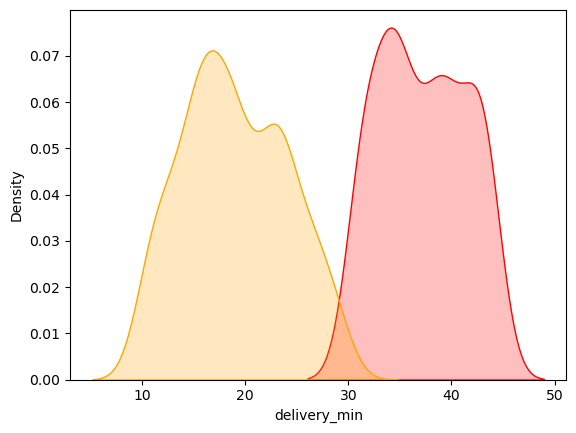

In [87]:
# Add legend
sb.kdeplot(sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0]["delivery_min"], color = "red", fill = True)
sb.kdeplot(sunny_traffic_low[sunny_traffic_low["rider_ratings"] == 5.0]["delivery_min"], color = "orange", fill = True)

###  Find the remaining 35 bad ratings out of total 140 bad ratings

### 1-score ratings

In [90]:
len(zomato[zomato["rider_ratings"] == 1][["weather","traffic"]])

35

In [6]:
zomato[zomato["rider_ratings"] == 1]["delivery_min"].mean()

26.02857142857143

In [124]:
zomato[zomato["rider_ratings"] == 1][["weather","traffic", "hour", "rider_age", "vehicle", "vehicle_condition"]]

,weather,traffic,hour,rider_age,vehicle,vehicle_condition
2251,Fog,Low,NaN,15.0,motorcycle,3
2739,Fog,Low,NaN,15.0,scooter,3
2784,Fog,Low,NaN,15.0,bicycle,3
5590,Fog,Low,NaN,15.0,bicycle,3
8684,Fog,Low,NaN,15.0,motorcycle,3
10354,Fog,Low,NaN,15.0,motorcycle,3
10573,Fog,Low,NaN,15.0,scooter,3
11486,Fog,Low,NaN,15.0,bicycle,3
14376,Fog,Low,NaN,15.0,bicycle,3
15145,Fog,Low,NaN,15.0,bicycle,3


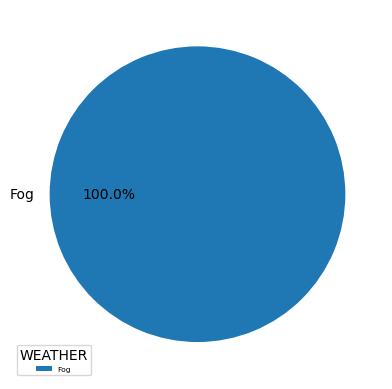

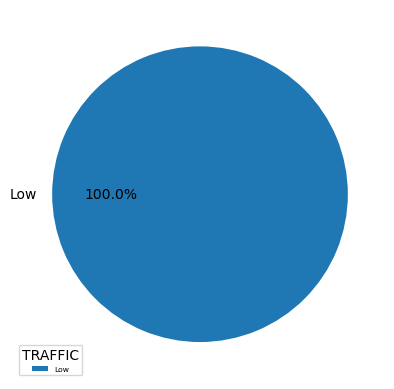

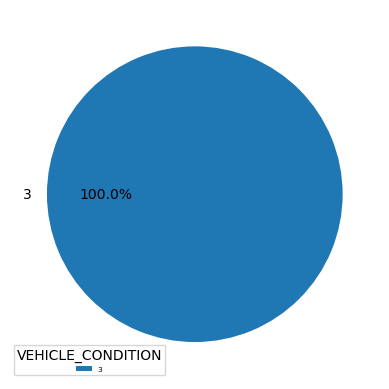

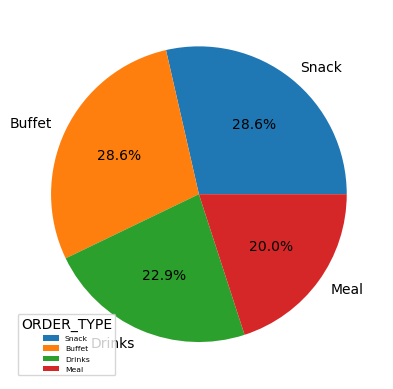

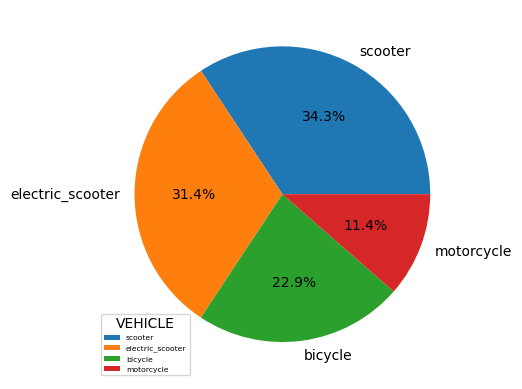

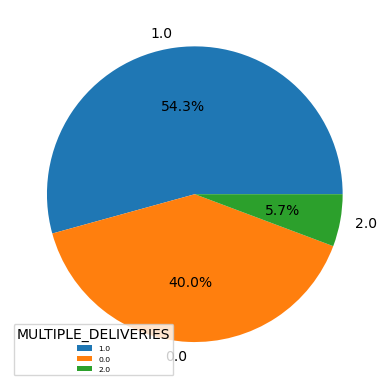

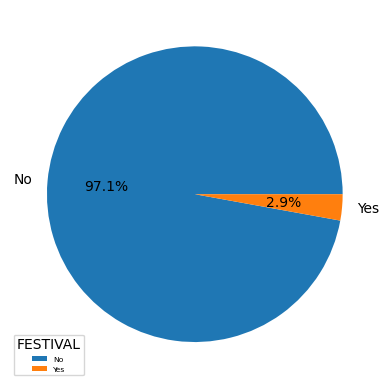

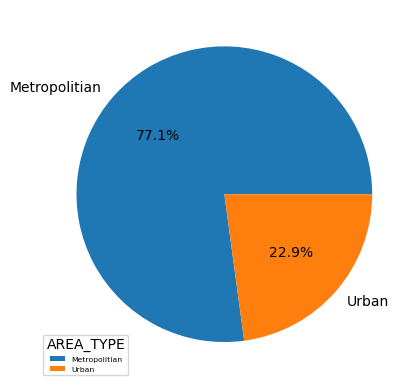

In [120]:
pie_chart(zomato[zomato["rider_ratings"] == 1][zomato_cats.columns])

<Axes: xlabel='delivery_min', ylabel='rider_ratings'>

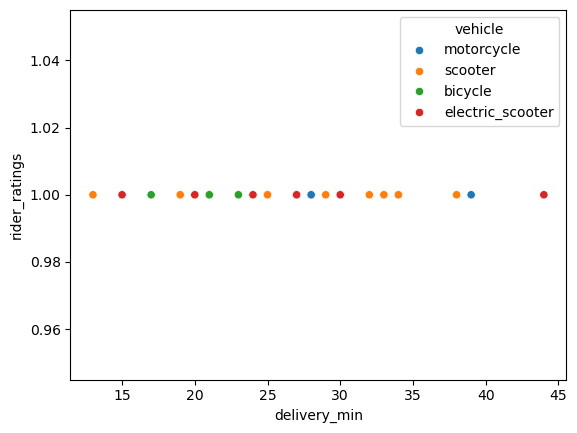

In [94]:
# 1-score ratings are from fog, low traffic conditions 
sb.scatterplot(x = "delivery_min", y = "rider_ratings", data = zomato[zomato["rider_ratings"] == 1], hue = "vehicle")

In [100]:
# The number of riders with ratings 1 and used bicycle for deliveries
len(zomato[(zomato["rider_ratings"] == 1)  & (zomato["vehicle"] == "bicycle")])

8

##### The 35 1-score ratings are made under foggy,  low traffic condition with all riders aged 15. 
##### Delivery times of 1 -score ratings are varied from 10 to 45 minutes 

<Axes: xlabel='delivery_min', ylabel='rider_age'>

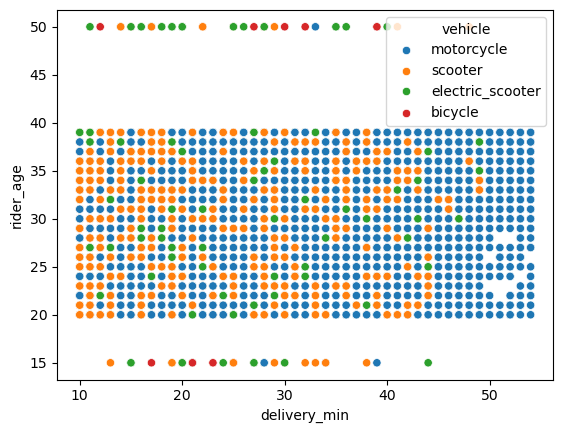

In [468]:
sb.scatterplot(x = "delivery_min", y = "rider_age", data = zomato, hue = "vehicle")

In [122]:
zomato.columns

Index(['order_id', 'rider_id', 'rider_age', 'rider_ratings',
       'restaurant_latitude', 'restaurant_longitude',
       'delivery_location_latitude', 'delivery_location_longitude',
       'order_date', 'time_ordered', 'time_picked', 'weather', 'traffic',
       'vehicle_condition', 'order_type', 'vehicle', 'multiple_deliveries',
       'festival', 'area_type', 'delivery_min', 'time_to_pick', 'month',
       'hour', 'peak_flag'],
      dtype='object')

In [ ]:
# Delivery time comparison of bad ratings: Sunny, low (2.5-3.0 ratings) vs Fog, Low (1-ratings)

<Axes: xlabel='delivery_min', ylabel='Density'>

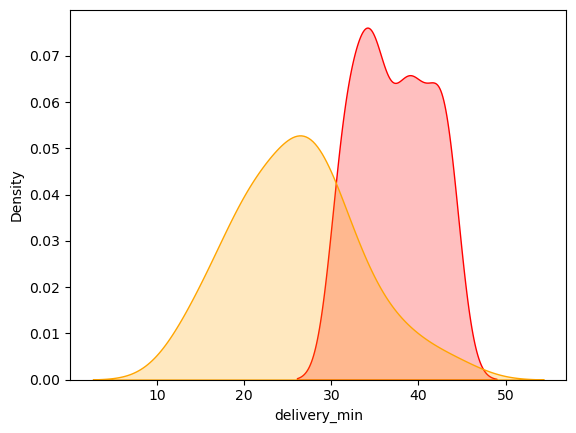

In [128]:
sb.kdeplot(sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.0]["delivery_min"], color = "red", fill = True)
sb.kdeplot(zomato[zomato["rider_ratings"] == 1]["delivery_min"], color = "orange", fill = True)

In [ ]:
개선 시뮬레이션 
1. Sunny, low traffic의 Bad ratings 경우, 배달 시간 30분을  기점으로 rating이 4.5 점에서 3.5점이하 대로 낮아짐 
- 배달시간 30분이상의 배달들의 배달시간을 30분 미만으로 만들경우 ratings가 얼마나 개선이 되는지 
    - 30분이상의 배달 수를 줄이거나 30분 미만의 배달 수를 늘려보기 

2. Fog, low traffic의 1점 ratings 경우, 라이더의 나이가 전부 15세, 배달수단의 상태가 3, 배달 수단으로 거의 쓰이지 않는 자전거 라이더의 비율이 전체 (15)의 반이상 (8)
- Fog, low 시간대에 10대 라이더의 배차를 지양했을 경우 (평균 나이의 라이더로 배차), ratings가 얼마나 개선되는지 

In [142]:
# Bad ratings on sunny, low traffic
sunny_traffic_low[(sunny_traffic_low["rider_ratings"] <= 3.0) & (sunny_traffic_low["delivery_min"] >=30)]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
365,0x8b39,VADRES01DEL01,24.0,2.6,22.307898,73.167788,22.417898,73.277788,2022-04-06,1900-01-01 22:35:00,...,Drinks,motorcycle,1.0,Yes,Metropolitian,42,15,4,22.0,0
542,0x5fd4,SURRES04DEL01,23.0,2.5,21.173493,72.801953,21.283493,72.911953,2022-03-20,1900-01-01 23:50:00,...,Buffet,motorcycle,1.0,No,Metropolitian,34,-153722867280912928,3,23.0,0
881,0xc714,BHPRES14DEL03,29.0,2.5,0.000000,0.000000,0.090000,0.090000,2022-02-18,1900-01-01 22:55:00,...,Drinks,scooter,1.0,Yes,Metropolitian,41,10,2,22.0,0
1256,0x2daf,HYDRES05DEL02,20.0,2.5,17.433809,78.386744,17.563809,78.516744,2022-03-18,1900-01-01 23:55:00,...,Snack,scooter,1.0,No,Metropolitian,43,-153722867280912928,3,23.0,0
1313,0xe247,LUDHRES20DEL01,23.0,2.6,30.885915,75.788259,30.995915,75.898259,2022-02-12,1900-01-01 23:25:00,...,Drinks,scooter,1.0,No,Metropolitian,43,15,2,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42138,0x2702,RANCHIRES04DEL03,22.0,2.7,23.359033,85.325347,23.449033,85.415347,2022-03-16,1900-01-01 23:55:00,...,Buffet,motorcycle,1.0,No,Metropolitian,32,-153722867280912928,3,23.0,0
42194,0xd6b0,DEHRES12DEL02,21.0,2.6,0.000000,0.000000,0.080000,0.080000,2022-02-16,1900-01-01 23:30:00,...,Snack,motorcycle,1.0,No,Metropolitian,34,5,2,23.0,0
42322,0x71fd,SURRES20DEL01,28.0,2.7,21.152760,72.778059,21.262760,72.888059,2022-03-04,1900-01-01 22:20:00,...,Meal,scooter,1.0,No,Metropolitian,35,10,3,22.0,0
42963,0x6c66,JAPRES12DEL03,22.0,2.9,26.902908,75.792934,26.992908,75.882934,2022-04-02,1900-01-01 22:50:00,...,Drinks,scooter,1.0,No,Metropolitian,33,-153722867280912928,4,22.0,0


In [150]:
sunny_traffic_low[(sunny_traffic_low["rider_ratings"] == 5.0) & (sunny_traffic_low["delivery_min"] <30)]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
29,0x4bda,HYDRES17DEL02,35.0,5.0,17.451976,78.385883,17.471976,78.405883,2022-04-01,1900-01-01 09:45:00,...,Snack,scooter,1.0,No,Urban,11,10,4,9.0,0
85,0x97e3,MYSRES16DEL02,29.0,5.0,12.316967,76.603067,12.366967,76.653067,2022-04-01,1900-01-01 22:20:00,...,Drinks,motorcycle,0.0,No,Metropolitian,18,5,4,22.0,0
499,0x9098,MUMRES19DEL03,20.0,5.0,19.131141,72.813074,19.191140,72.873074,2022-03-15,1900-01-01 23:15:00,...,Drinks,scooter,0.0,No,Metropolitian,17,5,3,23.0,0
658,0xbb43,RANCHIRES20DEL01,29.0,5.0,23.399250,85.390464,23.409250,85.400464,2022-03-07,1900-01-01 10:20:00,...,Buffet,motorcycle,0.0,No,Metropolitian,21,15,3,10.0,0
834,0x9566,SURRES08DEL03,28.0,5.0,21.173343,72.792731,21.203343,72.822731,2022-04-01,1900-01-01 23:45:00,...,Buffet,motorcycle,0.0,No,Urban,15,-153722867280912928,4,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42559,0x9c24,SURRES18DEL03,34.0,5.0,21.149834,72.778666,21.179834,72.808666,2022-04-03,1900-01-01 22:10:00,...,Buffet,scooter,1.0,No,Metropolitian,18,10,4,22.0,0
42633,0x907a,JAPRES04DEL02,23.0,5.0,26.902328,75.794257,26.922328,75.814257,2022-03-21,1900-01-01 08:10:00,...,Drinks,motorcycle,1.0,No,Metropolitian,20,5,3,8.0,0
43023,0xd631,DEHRES18DEL03,36.0,5.0,0.000000,0.000000,0.060000,0.060000,2022-02-17,1900-01-01 22:25:00,...,Meal,motorcycle,0.0,No,Metropolitian,17,5,2,22.0,0
43039,0x41cb,CHENRES07DEL01,33.0,5.0,13.081878,80.248519,13.151878,80.318519,2022-03-16,1900-01-01 22:10:00,...,Meal,motorcycle,1.0,No,Metropolitian,25,10,3,22.0,0


In [140]:
sunny_traffic_low[sunny_traffic_low["rider_ratings"] == 5.0]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
29,0x4bda,HYDRES17DEL02,35.0,5.0,17.451976,78.385883,17.471976,78.405883,2022-04-01,1900-01-01 09:45:00,...,Snack,scooter,1.0,No,Urban,11,10,4,9.0,0
85,0x97e3,MYSRES16DEL02,29.0,5.0,12.316967,76.603067,12.366967,76.653067,2022-04-01,1900-01-01 22:20:00,...,Drinks,motorcycle,0.0,No,Metropolitian,18,5,4,22.0,0
499,0x9098,MUMRES19DEL03,20.0,5.0,19.131141,72.813074,19.191140,72.873074,2022-03-15,1900-01-01 23:15:00,...,Drinks,scooter,0.0,No,Metropolitian,17,5,3,23.0,0
658,0xbb43,RANCHIRES20DEL01,29.0,5.0,23.399250,85.390464,23.409250,85.400464,2022-03-07,1900-01-01 10:20:00,...,Buffet,motorcycle,0.0,No,Metropolitian,21,15,3,10.0,0
834,0x9566,SURRES08DEL03,28.0,5.0,21.173343,72.792731,21.203343,72.822731,2022-04-01,1900-01-01 23:45:00,...,Buffet,motorcycle,0.0,No,Urban,15,-153722867280912928,4,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42559,0x9c24,SURRES18DEL03,34.0,5.0,21.149834,72.778666,21.179834,72.808666,2022-04-03,1900-01-01 22:10:00,...,Buffet,scooter,1.0,No,Metropolitian,18,10,4,22.0,0
42633,0x907a,JAPRES04DEL02,23.0,5.0,26.902328,75.794257,26.922328,75.814257,2022-03-21,1900-01-01 08:10:00,...,Drinks,motorcycle,1.0,No,Metropolitian,20,5,3,8.0,0
43023,0xd631,DEHRES18DEL03,36.0,5.0,0.000000,0.000000,0.060000,0.060000,2022-02-17,1900-01-01 22:25:00,...,Meal,motorcycle,0.0,No,Metropolitian,17,5,2,22.0,0
43039,0x41cb,CHENRES07DEL01,33.0,5.0,13.081878,80.248519,13.151878,80.318519,2022-03-16,1900-01-01 22:10:00,...,Meal,motorcycle,1.0,No,Metropolitian,25,10,3,22.0,0


In [132]:
sunny_traffic_low[sunny_traffic_low["rider_ratings"] <= 3.5]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
365,0x8b39,VADRES01DEL01,24.0,2.6,22.307898,73.167788,22.417898,73.277788,2022-04-06,1900-01-01 22:35:00,...,Drinks,motorcycle,1.0,Yes,Metropolitian,42,15,4,22.0,0
542,0x5fd4,SURRES04DEL01,23.0,2.5,21.173493,72.801953,21.283493,72.911953,2022-03-20,1900-01-01 23:50:00,...,Buffet,motorcycle,1.0,No,Metropolitian,34,-153722867280912928,3,23.0,0
569,0xa635,PUNERES14DEL01,22.0,3.5,18.516216,73.842527,18.586216,73.912527,2022-03-25,1900-01-01 23:40:00,...,Meal,motorcycle,0.0,No,Metropolitian,33,10,3,23.0,0
881,0xc714,BHPRES14DEL03,29.0,2.5,0.000000,0.000000,0.090000,0.090000,2022-02-18,1900-01-01 22:55:00,...,Drinks,scooter,1.0,Yes,Metropolitian,41,10,2,22.0,0
1256,0x2daf,HYDRES05DEL02,20.0,2.5,17.433809,78.386744,17.563809,78.516744,2022-03-18,1900-01-01 23:55:00,...,Snack,scooter,1.0,No,Metropolitian,43,-153722867280912928,3,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42427,0xb12b,MYSRES06DEL02,36.0,3.3,12.323994,76.626167,12.403994,76.706167,2022-03-20,1900-01-01 22:50:00,...,Meal,motorcycle,2.0,No,Metropolitian,34,5,3,22.0,0
42820,0xd5fd,GOARES08DEL01,31.0,3.4,15.556561,73.763633,15.626561,73.833633,2022-02-18,1900-01-01 22:15:00,...,Snack,motorcycle,0.0,No,Metropolitian,33,5,2,22.0,0
42963,0x6c66,JAPRES12DEL03,22.0,2.9,26.902908,75.792934,26.992908,75.882934,2022-04-02,1900-01-01 22:50:00,...,Drinks,scooter,1.0,No,Metropolitian,33,-153722867280912928,4,22.0,0
43025,0xa26b,BANGRES12DEL01,25.0,2.7,12.939496,77.625999,13.009496,77.695999,2022-03-18,1900-01-01 23:35:00,...,Snack,motorcycle,2.0,No,Metropolitian,39,10,3,23.0,0


In [3]:
##### Delivery ratings prediction 

In [156]:
##### 데이터 합치기
sunny_3 = sunny_traffic_low[(sunny_traffic_low["rider_ratings"] <= 3.0)]
sunny_5 = sunny_traffic_low[(sunny_traffic_low["rider_ratings"] == 5.0)]
frames = [sunny_3,sunny_5]
sunny_3_5 = pd.concat(frames)
sunny_3_5

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
365,0x8b39,VADRES01DEL01,24.0,2.6,22.307898,73.167788,22.417898,73.277788,2022-04-06,1900-01-01 22:35:00,...,Drinks,motorcycle,1.0,Yes,Metropolitian,42,15,4,22.0,0
542,0x5fd4,SURRES04DEL01,23.0,2.5,21.173493,72.801953,21.283493,72.911953,2022-03-20,1900-01-01 23:50:00,...,Buffet,motorcycle,1.0,No,Metropolitian,34,-153722867280912928,3,23.0,0
881,0xc714,BHPRES14DEL03,29.0,2.5,0.000000,0.000000,0.090000,0.090000,2022-02-18,1900-01-01 22:55:00,...,Drinks,scooter,1.0,Yes,Metropolitian,41,10,2,22.0,0
1256,0x2daf,HYDRES05DEL02,20.0,2.5,17.433809,78.386744,17.563809,78.516744,2022-03-18,1900-01-01 23:55:00,...,Snack,scooter,1.0,No,Metropolitian,43,-153722867280912928,3,23.0,0
1313,0xe247,LUDHRES20DEL01,23.0,2.6,30.885915,75.788259,30.995915,75.898259,2022-02-12,1900-01-01 23:25:00,...,Drinks,scooter,1.0,No,Metropolitian,43,15,2,23.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42559,0x9c24,SURRES18DEL03,34.0,5.0,21.149834,72.778666,21.179834,72.808666,2022-04-03,1900-01-01 22:10:00,...,Buffet,scooter,1.0,No,Metropolitian,18,10,4,22.0,0
42633,0x907a,JAPRES04DEL02,23.0,5.0,26.902328,75.794257,26.922328,75.814257,2022-03-21,1900-01-01 08:10:00,...,Drinks,motorcycle,1.0,No,Metropolitian,20,5,3,8.0,0
43023,0xd631,DEHRES18DEL03,36.0,5.0,0.000000,0.000000,0.060000,0.060000,2022-02-17,1900-01-01 22:25:00,...,Meal,motorcycle,0.0,No,Metropolitian,17,5,2,22.0,0
43039,0x41cb,CHENRES07DEL01,33.0,5.0,13.081878,80.248519,13.151878,80.318519,2022-03-16,1900-01-01 22:10:00,...,Meal,motorcycle,1.0,No,Metropolitian,25,10,3,22.0,0


In [158]:
# Export for Linear Regression Analysis
sunny_3_5.to_csv("C:/Users/minjk/Downloads/sunny_3_5.csv" , index = False, encoding = 'utf-8')

In [ ]:
KPI 리포트 

In [185]:
# Modeling to predict 

In [416]:
stats.shapiro(df["rider_ratings"])

ShapiroResult(statistic=0.5846178734279373, pvalue=2.1666377305005973e-59)

In [422]:
ks,pval = kstest(df["rider_ratings"], 'norm', args =
                               (df["rider_ratings"].mean(),df["rider_ratings"].std()))
print(ks,pval)

0.33989807166848374 2.060920386874191e-240


## rider_ratings 정규분포로 변환해야한다 

<Axes: xlabel='rider_ratings', ylabel='Count'>

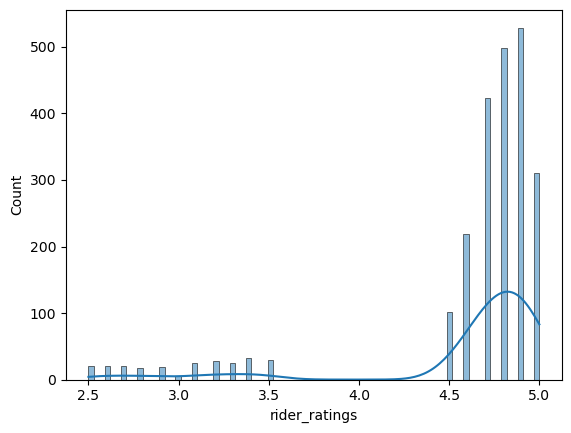

In [38]:
sb.histplot(x = "rider_ratings", data = sunny_traffic_low, kde = True)


In [ ]:
# Box Cox Transformation of Rider ratings 

Optimal Lambda (λ): 9.992437178060344


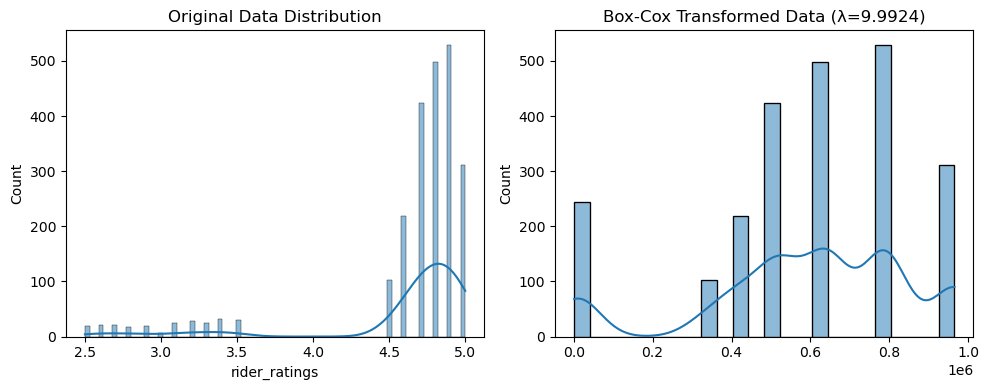

In [42]:
import numpy as np
# Apply Box-Cox transformation
transformed_data, lambda_value = stats.boxcox(sunny_traffic_low["rider_ratings"])

print(f"Optimal Lambda (λ): {lambda_value}")

# Plot the original and transformed data to see the effect
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sb.histplot(sunny_traffic_low["rider_ratings"], kde=True, ax=ax1)
ax1.set_title("Original Data Distribution")

sb.histplot(transformed_data, kde=True, ax=ax2)
ax2.set_title(f"Box-Cox Transformed Data (λ={lambda_value:.4f})")

plt.tight_layout()
plt.show()

In [54]:
stats.shapiro(transformed_data)
transformed_data

array([965478.00887077, 419656.99570845, 965478.00887077, ...,
       520264.4039348 , 788986.34800852, 642079.45437513])

In [429]:
import statsmodels.api as sm
df = sunny_traffic_low # exported sql table 
sunny_traffic_low["deliverytime_more30"] = (sunny_traffic_low["delivery_min"] >= 30).astype(int)
X = df["deliverytime_more30"] # feature variables of interest
X = sm.add_constant(X) # 1로 이우러진 컬럼 추가 -> 절편항 추정
y = df["rider_ratings"]

model = sm.OLS(y,X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          rider_ratings   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                 1.221e+04
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:36:23   Log-Likelihood:                 172.92
No. Observations:                2327   AIC:                            -341.8
Df Residuals:                    2325   BIC:                            -330.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.7997    

In [24]:
import statsmodels.api as sm
df = sunny_traffic_low # exported sql table 
X = df["delivery_min"] - 30 # feature variables of interest
X = sm.add_constant(X) # 1로 이우러진 컬럼 추가 -> 절편항 추정
y = df["rider_ratings"]

model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          rider_ratings   R-squared:                       0.486
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     2198.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:52:02   Log-Likelihood:                -1185.8
No. Observations:                2327   AIC:                             2376.
Df Residuals:                    2325   BIC:                             2387.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.1595      0.013    324.435   

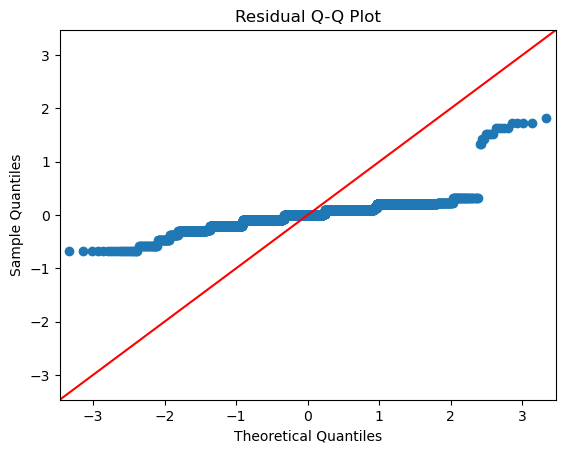

In [435]:
from statsmodels.graphics.gofplots import qqplot

fig = qqplot(model.resid, line='45')
plt.title("Residual Q-Q Plot")
plt.show()

In [405]:
sunny_traffic_low["deliverytime_more30"] = (sunny_traffic_low["delivery_min"] >= 30).astype(int)
sunny_traffic_low["deliverytime_more30"].value_counts()

deliverytime_more30
0    2063
1     264
Name: count, dtype: int64

##### 3.3. Distribution of Average Rider Ratings of the distinct riders
- Since we evaluated the overall ratings without accounting for distinct rider,
- We will focus on each rider's performance by evaluating the average rider's ratings for each distinct riders

##### What is the number ratings received by each distinct rider? 
- The number of ratings received are equal to the number of deliveries made by each rider

In [145]:
zomato.groupby(zomato["rider_id"])["rider_ratings"].count()

rider_id
AGRRES010DEL01    13
AGRRES010DEL02    14
AGRRES010DEL03    13
AGRRES01DEL01      9
AGRRES01DEL02     14
                  ..
VADRES19DEL02     57
VADRES19DEL03     38
VADRES20DEL01     56
VADRES20DEL02     48
VADRES20DEL03     34
Name: rider_ratings, Length: 1320, dtype: int64

Text(0.5, 0, 'Number of ratings received')

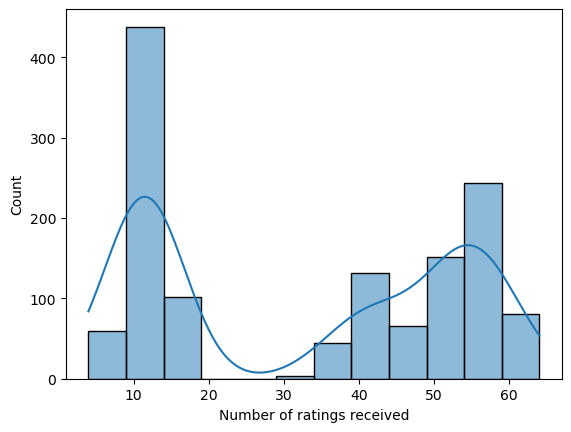

In [147]:
sb.histplot(zomato.groupby(zomato["rider_id"])["rider_ratings"].count(), kde  = True)
plt.xlabel("Number of ratings received")

In [135]:
zomato.groupby(zomato["rider_id"])["rider_ratings"].count().describe()

count    1320.000000
mean       32.758333
std        20.290160
min         4.000000
25%        12.000000
50%        39.000000
75%        53.000000
max        64.000000
Name: rider_ratings, dtype: float64

Text(0.5, 0, 'Number of ratings received')

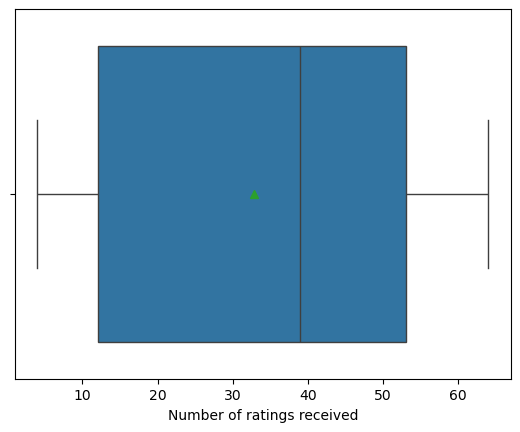

In [137]:
sb.boxplot(zomato.groupby(zomato["rider_id"])["rider_ratings"].count(), orient = "h", showmeans = True)
plt.xlabel("Number of ratings received")

##### On average, each distinct rider received 32 ratings in 2-month period. 

<Axes: xlabel='rider_ratings', ylabel='Count'>

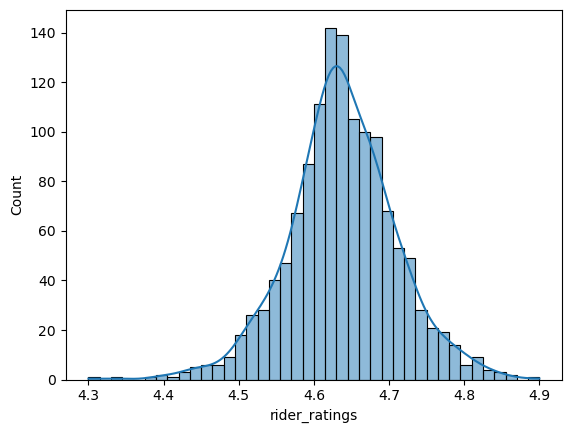

In [108]:
# What is the distribution of the average delivery time of the distinct riders? 
# Find the average rating of the distinct riders

avg_ratings = zomato.groupby(zomato["rider_id"])["rider_ratings"].mean()

sb.histplot(avg_ratings, kde = True)

In [121]:
avg_ratings.describe()

count    1320.000000
mean        4.637524
std         0.072069
min         4.300000
25%         4.596412
50%         4.636364
75%         4.680390
max         4.900000
Name: rider_ratings, dtype: float64

##### The average delivery ratings of a single rider ranges from 4.3 to 4.9 with average delivery ratings with 4.6.

##### 3.4. Distinct Rider: Good and Bad Rating 

##### Bad Ratings by rider: Among ratings less than or equal to 3, find the number of the distinct riders and their average ratings

### This does not mean that a distinct rider received average rating less than or equal to 3 since only the ratings less than or equal to 3 will be used and the higher ratings by a distinct rider are not accounted 

In [205]:
avg_delivery_3ratings = zomato[(zomato["rider_ratings"] <= 3.0)].groupby(zomato["rider_id"])["rider_ratings"].mean()
avg_delivery_3ratings 

rider_id
AGRRES13DEL02      2.6
BANGRES010DEL01    2.5
BANGRES010DEL03    2.5
BANGRES01DEL01     2.6
BANGRES02DEL01     2.6
                  ... 
VADRES04DEL01      1.0
VADRES06DEL03      2.7
VADRES07DEL02      2.8
VADRES09DEL01      2.8
VADRES11DEL03      2.5
Name: rider_ratings, Length: 130, dtype: float64

##### Among all ratings less than or equal to 3, there are 130 distinct riders with average rider ratings less than or equal to 3.


In [251]:
# List of 130 distinct riders with average rider ratings less than or equal to 3 
avg_delivery_3ratings.index

Index(['AGRRES13DEL02', 'BANGRES010DEL01', 'BANGRES010DEL03', 'BANGRES01DEL01',
       'BANGRES02DEL01', 'BANGRES02DEL02', 'BANGRES02DEL03', 'BANGRES05DEL01',
       'BANGRES05DEL03', 'BANGRES07DEL03',
       ...
       'SURRES12DEL01', 'SURRES16DEL01', 'SURRES17DEL03', 'SURRES20DEL01',
       'VADRES01DEL01', 'VADRES04DEL01', 'VADRES06DEL03', 'VADRES07DEL02',
       'VADRES09DEL01', 'VADRES11DEL03'],
      dtype='object', name='rider_id', length=130)

In [257]:
# Dataset with thh List of 130 distinct riders with average rider ratings less than or equal to 3 
zomato[zomato["rider_id"].isin(avg_delivery_3ratings.index)]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,1900-01-01 17:30:00,...,Drinks,scooter,1.0,No,Metropolitian,21,10,3,17.0,0
7,0x689b,PUNERES20DEL01,33.0,4.2,18.592718,73.773572,18.702718,73.883572,2022-03-16,1900-01-01 20:30:00,...,Snack,motorcycle,1.0,No,Metropolitian,40,10,3,20.0,1
14,0x539b,MUMRES02DEL01,25.0,4.0,19.221315,72.862381,19.261315,72.902381,2022-03-26,1900-01-01 12:25:00,...,Buffet,motorcycle,1.0,No,Metropolitian,34,5,3,12.0,0
24,0x2876,RANCHIRES02DEL01,32.0,3.5,0.000000,0.000000,0.110000,0.110000,2022-03-08,1900-01-01 21:35:00,...,Snack,scooter,0.0,No,Urban,35,10,3,21.0,0
26,0xb843,PUNERES02DEL01,33.0,4.9,18.551440,73.804855,18.621440,73.874855,2022-03-08,1900-01-01 18:55:00,...,Snack,motorcycle,1.0,No,Metropolitian,22,15,3,18.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43231,0x5193,MYSRES13DEL02,36.0,4.8,12.310972,76.659264,12.440972,76.789264,2022-03-18,1900-01-01 21:10:00,...,Drinks,electric_scooter,1.0,No,Urban,29,10,3,21.0,0
43232,0xa333,CHENRES08DEL02,37.0,4.8,13.022394,80.242439,13.042394,80.262439,2022-04-05,1900-01-01 09:35:00,...,Drinks,electric_scooter,0.0,No,Metropolitian,20,15,4,9.0,0
43235,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,1900-01-01 21:45:00,...,Drinks,motorcycle,1.0,No,Metropolitian,33,10,3,21.0,0
43239,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,1900-01-01 13:35:00,...,Snack,motorcycle,1.0,No,Metropolitian,26,5,3,13.0,0


In [243]:
avg_delivery_3ratings.describe()

count    130.000000
mean       2.283269
std        0.743365
min        1.000000
25%        1.875000
50%        2.600000
75%        2.800000
max        3.000000
Name: rider_ratings, dtype: float64

<Axes: xlabel='rider_ratings'>

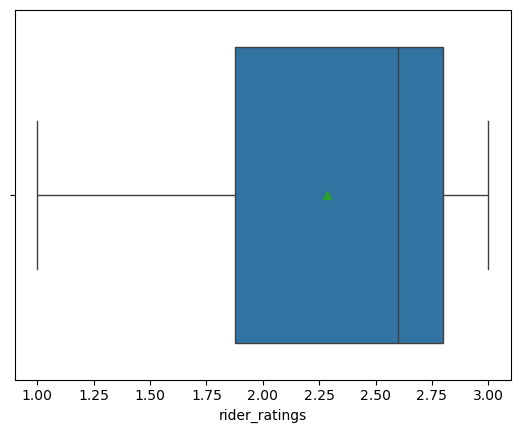

In [245]:
sb.boxplot(avg_delivery_3ratings, showmeans = True, orient= "h")

##### Average delivery times of the group of the average rider ratings less than or equal to 3


In [197]:
zomato[(zomato["rider_ratings"] <= 3.0)].groupby(zomato["rider_id"])["delivery_min"].mean().describe()

count    130.000000
mean      34.346154
std        6.896479
min       13.000000
25%       31.000000
50%       35.000000
75%       39.000000
max       44.000000
Name: delivery_min, dtype: float64

<Axes: xlabel='delivery_min', ylabel='Count'>

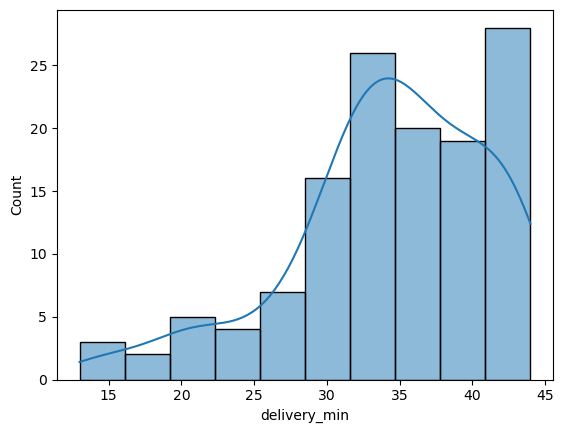

In [285]:
# Delivery times of the average rider ratings less than or equal to 3
avg_delivery_3ratings = zomato[(zomato["rider_ratings"] <= 3.0)].groupby(zomato["rider_id"])["delivery_min"].mean()
sb.histplot(avg_delivery_3ratings, kde = True)

#zomato[(zomato["rider_ratings"] >= 3.0) & (zomato["rider_ratings"] <= 3.9)]
#zomato[(zomato["rider_ratings"] >= 4.0) & (zomato["rider_ratings"] <= 4.9)]

##### Good Ratings by Rider: Among ratings equal to 5, find the number of the distinct riders and their average delivery time.

In [226]:
avg_delivery_5ratings = zomato[(zomato["rider_ratings"] == 5.0)].groupby(zomato["rider_id"])["delivery_min"].mean()
print(avg_delivery_5ratings)

rider_id
AGRRES010DEL01    21.000000
AGRRES010DEL02    20.666667
AGRRES02DEL01     33.500000
AGRRES02DEL02     15.000000
AGRRES02DEL03     25.000000
                    ...    
VADRES19DEL02     24.500000
VADRES19DEL03     25.142857
VADRES20DEL01     30.857143
VADRES20DEL02     24.000000
VADRES20DEL03     27.200000
Name: delivery_min, Length: 1128, dtype: float64


##### Among all ratings equal  to 5, there are 1128 distinct riders with average rider ratings equal to 5.

In [247]:
# List of 1128 distinct riders with average rider ratings equal to 5.
avg_delivery_5ratings.index

Index(['AGRRES010DEL01', 'AGRRES010DEL02', 'AGRRES02DEL01', 'AGRRES02DEL02',
       'AGRRES02DEL03', 'AGRRES03DEL01', 'AGRRES04DEL01', 'AGRRES04DEL02',
       'AGRRES04DEL03', 'AGRRES05DEL01',
       ...
       'VADRES17DEL03', 'VADRES18DEL01', 'VADRES18DEL02', 'VADRES18DEL03',
       'VADRES19DEL01', 'VADRES19DEL02', 'VADRES19DEL03', 'VADRES20DEL01',
       'VADRES20DEL02', 'VADRES20DEL03'],
      dtype='object', name='rider_id', length=1128)

In [259]:
# Dataset with thh List of 130 distinct riders with average rider ratings less than or equal to 3 
zomato[zomato["rider_id"].isin(avg_delivery_5ratings.index)]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,1900-01-01 21:55:00,...,Snack,motorcycle,3.0,No,Metropolitian,46,15,2,21.0,0
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,1900-01-01 14:55:00,...,Meal,motorcycle,1.0,No,Metropolitian,23,10,2,14.0,0
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,1900-01-01 17:30:00,...,Drinks,scooter,1.0,No,Metropolitian,21,10,3,17.0,0
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,1900-01-01 19:50:00,...,Snack,scooter,1.0,No,Metropolitian,41,15,2,19.0,1
5,0x3af3,MUMRES15DEL03,29.0,4.5,19.176269,72.836721,19.266269,72.926721,2022-04-02,1900-01-01 20:25:00,...,Buffet,electric_scooter,1.0,No,Metropolitian,20,10,4,20.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43235,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,1900-01-01 21:45:00,...,Drinks,motorcycle,1.0,No,Metropolitian,33,10,3,21.0,0
43236,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,1900-01-01 11:35:00,...,Meal,motorcycle,0.0,No,Metropolitian,32,10,3,11.0,0
43238,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,1900-01-01 23:50:00,...,Drinks,scooter,0.0,No,Metropolitian,16,-153722867280912928,3,23.0,0
43239,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,1900-01-01 13:35:00,...,Snack,motorcycle,1.0,No,Metropolitian,26,5,3,13.0,0


##### Average delivery times of the group of the average rider ratings equal to 5

In [233]:
avg_delivery_5ratings.describe()

count    50.000000
mean     24.200000
std       8.542809
min      11.000000
25%      17.250000
50%      22.000000
75%      28.000000
max      48.000000
Name: delivery_min, dtype: float64

<Axes: xlabel='delivery_min', ylabel='Count'>

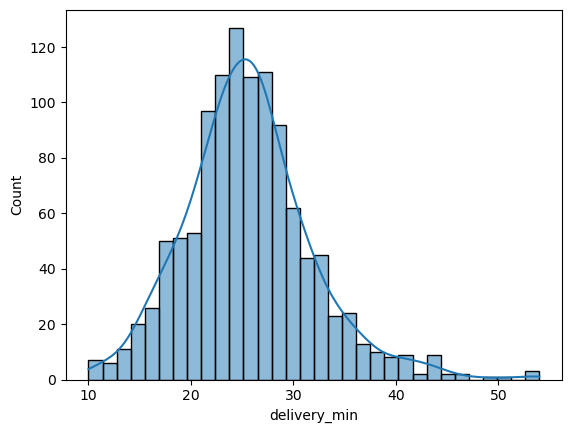

In [289]:
# Find the distribution of the delivery times of the group of the average rider ratings equal to 5
sb.histplot(avg_delivery_5ratings, kde = True)

#### Undersampling: Obtain random subset: 10% of the dataset: 113 distinct riders with the average rating of 5 
##### to compare with the 130 distinct riders with the average rating less than or equal to 3.

In [ ]:
##### We can assume that the longer deliveries (more than 30-minute) made on sunny, low-traffic days are rated more harshly than the shorter deliveries made under same condition (suuny, low).
##### We can check the assumption by taking a random sample of the same size as ratings 3 group from the group of ratings equal to 5 to compare the weather and traffic conditions.

In [291]:
# Obtain random subset: 10% of the dataset: 113 distinct riders with the average rating of 5 to compare with the 
# 130 distinct riders with the average rating less than or equal to 3 
#import random
#random.seed()

from sklearn.model_selection import train_test_split
train, test = train_test_split(avg_delivery_5ratings, test_size = 0.1)
print("The random subset, 10% of the dataset, contains",len(test), "distinct riders") 

The random subset, 10% of the dataset, contains 113 distinct riders


<Axes: xlabel='delivery_min', ylabel='Count'>

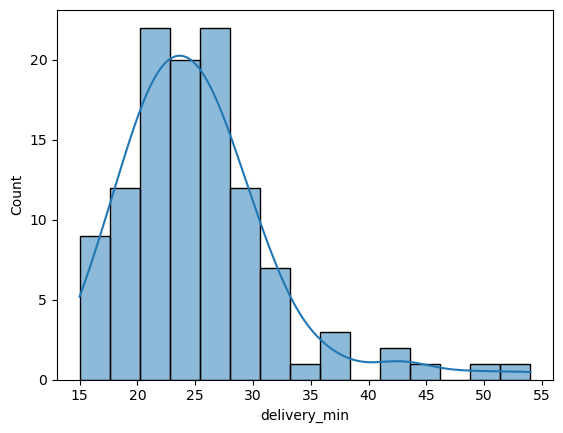

In [293]:
sb.histplot(test, kde = True)

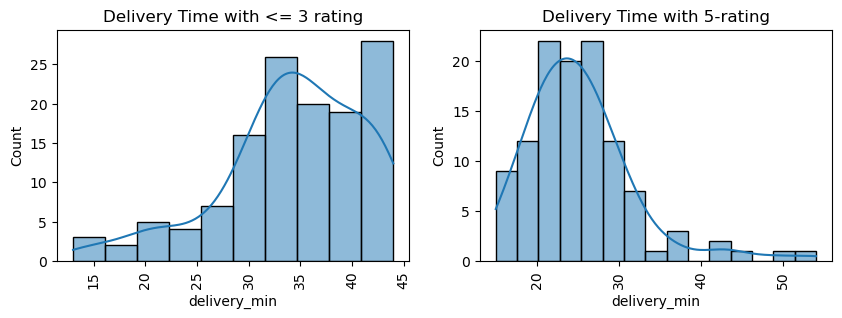

In [295]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (10, 3))

sb.histplot(avg_delivery_3ratings, ax = ax1, kde = True)
ax1.set_title('Delivery Time with <= 3 rating')

sb.histplot(test, ax = ax2,kde = True)
ax2.set_title("Delivery Time with 5-rating")

for ax in [ax1, ax2]:
    for tick in ax.get_xticklabels():
        tick.set_rotation(90);

<Axes: xlabel='delivery_min', ylabel='Density'>

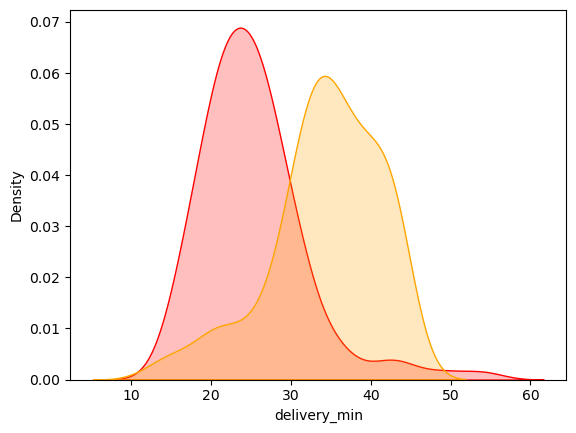

In [325]:
#zomato_data.loc[zomato_data.rider_age.isna(), "delivery_min"]
sb.kdeplot(test, color = "red", fill = True)
sb.kdeplot(avg_delivery_3ratings, color = "orange", fill = True)

##### Hypothesis Testing : 가설검정 


##### Compare the average delivery times of the two groups: 
##### 1. 113 distinct riders with an average rating of 3 or less vs. 
##### 2. 130 random distinct riders with an average rating of 5 

#### Check t-test assumptions: Normality of the average delivery time of 3 ratings and average delivery time of 5 ratings

#### Shapiro Wilk's Test of Normality

In [303]:
# Normality test
import scipy.stats as stats 

stats.shapiro(avg_delivery_3ratings)

ShapiroResult(statistic=0.9339916551272148, pvalue=8.078666271499713e-06)

In [305]:
stats.shapiro(avg_delivery_5ratings)

ShapiroResult(statistic=0.9736562825176045, pvalue=1.844193890663703e-13)

In [307]:
# Kologrove-Smirnov Test for Normality of large sample 

In [309]:
from scipy.stats import kstest

ks_statistic, p_value = kstest(avg_delivery_3ratings, 'norm', args =
                               (avg_delivery_3ratings.mean(), avg_delivery_3ratings.std()))
print(ks_statistic, p_value)

0.1137681484073152 0.06379052669752794


In [311]:
ks_statistic, p_value = kstest(avg_delivery_5ratings, 'norm', args =
                               (avg_delivery_5ratings.mean(), avg_delivery_5ratings.std()))
print(ks_statistic, p_value)

0.06985039178501384 3.134434466624185e-05


In [ ]:
# Check skewness and kurtosis 
# https://imaging.mrc-cbu.cam.ac.uk/statswiki/FAQ/Simon


In [313]:
# Skewness
print(avg_delivery_3ratings.skew())

# Kurtosis
print(avg_delivery_3ratings.kurt())

-0.8730539857992784
0.6478562804395125


In [66]:
# Skewness
print(avg_delivery_5ratings.skew())

# Kurtosis
print(avg_delivery_5ratings.kurt())

0.658595586803141
1.5693943391796323


In [56]:
# Avg delivery times of 3 ratings and 5 ratings do not follow a normal distribution
# We might need to transform the data to follow the normal distribution and
# perform the test for normality with the transformed data for the tt

In [315]:
from scipy.stats import ttest_ind

stat, pval = ttest_ind(avg_delivery_3ratings, test)
print(avg_delivery_3ratings.mean(), test.mean(), stat, pval)

34.34615384615385 25.195603315072344 10.543515381122505 1.279698701010429e-21


### 1. 문제정의: 
1) 3 >= score rating 과 5 score rating 의 평균 배달 시간의 차이가 통게적으로 유의미 p-value: 5.259597050495775e-42 < 0.05
2)  3 >= score rating 과 5 score rating 평균 배달 시간의 차이의 주요 원인이 무엇인가 (Delivery time이 주요 원인?)

- 주성분 분석 
- 주요 변수 selection: feature selection 


#### 3.3 Delivery Orders by each distinct riders 

##### 3.3.1. Identify the number of distinct riders


In [158]:
# print(zomato["rider_id"].unique())
#unique_riders = zomato["rider_id"].unique()
print("There are", zomato["rider_id"].nunique(), "distinct riders.")

There are 1320 distinct riders.


##### 3.3.2. Identify the number of deliveries by distinct rider


In [146]:
zomato.groupby(zomato["rider_id"])["order_id"].count()
# Output: Rider ID : Number of Deliveries made by each rider 

rider_id
AGRRES010DEL01    13
AGRRES010DEL02    14
AGRRES010DEL03    13
AGRRES01DEL01      9
AGRRES01DEL02     14
                  ..
VADRES19DEL02     57
VADRES19DEL03     38
VADRES20DEL01     56
VADRES20DEL02     48
VADRES20DEL03     34
Name: order_id, Length: 1320, dtype: int64

In [341]:
zomato.groupby(zomato["rider_id"])["order_id"].count().describe()

count    1320.000000
mean       32.758333
std        20.290160
min         4.000000
25%        12.000000
50%        39.000000
75%        53.000000
max        64.000000
Name: order_id, dtype: float64

##### The number of orders delivered by a rider during 2-month period ranges from 4 to 64 orders with 32 orders on average.

<Axes: xlabel='order_id', ylabel='Count'>

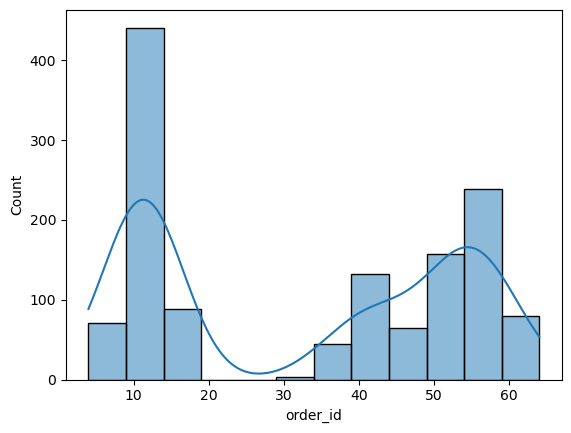

In [314]:
sb.histplot(zomato.groupby(zomato["rider_id"])["order_id"].count(), kde  = True)

#### We can divide the riders into two groups based on the criteria:
- "Delivers orders less than or equal to 30" or
- "Delivers orders greater 30"

##### "Delivers orders less than or equal to 30" 

In [327]:
order_count = pd.DataFrame(data= zomato.groupby(zomato["rider_id"])["order_id"].count())
order_count[order_count["order_id"] <= 30]

,order_id
rider_id,
AGRRES010DEL01,13
AGRRES010DEL02,14
AGRRES010DEL03,13
AGRRES01DEL01,9
AGRRES01DEL02,14
...,...
LUDHRES19DEL02,10
LUDHRES19DEL03,10
LUDHRES20DEL01,12


##### There are 600 distinct riders with the number of delivery orders less than or equal to 30

In [366]:
# list of riders with less than or equal to 30 deliveries
order_count[order_count["order_id"] <= 30].index

Index(['AGRRES010DEL01', 'AGRRES010DEL02', 'AGRRES010DEL03', 'AGRRES01DEL01',
       'AGRRES01DEL02', 'AGRRES01DEL03', 'AGRRES02DEL01', 'AGRRES02DEL02',
       'AGRRES02DEL03', 'AGRRES03DEL01',
       ...
       'LUDHRES17DEL03', 'LUDHRES18DEL01', 'LUDHRES18DEL02', 'LUDHRES18DEL03',
       'LUDHRES19DEL01', 'LUDHRES19DEL02', 'LUDHRES19DEL03', 'LUDHRES20DEL01',
       'LUDHRES20DEL02', 'LUDHRES20DEL03'],
      dtype='object', name='rider_id', length=600)

In [368]:
# Get delivery information with the list of riders 
ridersID_less30 = list(order_count[order_count["order_id"] <= 30].index)

riders_less30 = zomato[zomato["rider_id"].isin(ridersID_less30)]
# list of riders with less than or equal to 30 deliveries
#order_count[order_count["order_id"] <= 30].index
#i = 0
#for rider_id in list_of_riders: 
 #   if zomato[rider_id][i] == rider_id:
riders_less30     

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,traffic,vehicle_condition,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,1900-01-01 21:55:00,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,15,2
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,1900-01-01 14:55:00,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,10,2
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,1900-01-01 09:20:00,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,10,2
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,1900-01-01 19:50:00,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,15,2
9,0xc9cf,KOLRES15DEL03,21.0,4.7,22.552672,88.352885,22.582672,88.382885,2022-02-15,1900-01-01 21:15:00,...,Jam,0,Meal,motorcycle,1.0,No,Urban,15,15,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43211,0xd5c3,DEHRES04DEL02,34.0,4.5,30.340722,78.060221,30.470722,78.190221,2022-02-12,1900-01-01 19:35:00,...,Jam,2,Buffet,electric_scooter,1.0,No,Urban,27,10,2
43218,0xc7a7,AURGRES07DEL02,22.0,4.9,19.875908,75.358888,19.895908,75.378888,2022-02-11,1900-01-01 09:30:00,...,Low,2,Buffet,electric_scooter,0.0,No,Urban,12,15,2
43227,0xdf1d,BHPRES19DEL02,32.0,4.6,0.000000,0.000000,0.050000,0.050000,2022-02-15,1900-01-01 18:10:00,...,Medium,2,Drinks,scooter,1.0,No,Metropolitian,27,10,2
43233,0xc9ab,KNPRES03DEL01,30.0,4.2,26.469003,80.316344,26.539003,80.386344,2022-02-14,1900-01-01 18:10:00,...,Medium,1,Snack,motorcycle,2.0,Yes,Metropolitian,42,15,2


##### There are 6858 delivery information of 600 distinct riders who delivers less than or equal to 30 orders during 2-month period

##### "Delivers orders greater 30"

In [272]:
order_count[order_count["order_id"] > 30]

,order_id
rider_id,
BANGRES010DEL01,61
BANGRES010DEL02,57
BANGRES010DEL03,39
BANGRES01DEL01,58
BANGRES01DEL02,59
...,...
VADRES19DEL02,57
VADRES19DEL03,38
VADRES20DEL01,56


In [270]:
# List of riders with more than 30 deliveries 
order_count[order_count["order_id"] > 30].index

Index(['BANGRES010DEL01', 'BANGRES010DEL02', 'BANGRES010DEL03',
       'BANGRES01DEL01', 'BANGRES01DEL02', 'BANGRES01DEL03', 'BANGRES02DEL01',
       'BANGRES02DEL02', 'BANGRES02DEL03', 'BANGRES03DEL01',
       ...
       'VADRES17DEL03', 'VADRES18DEL01', 'VADRES18DEL02', 'VADRES18DEL03',
       'VADRES19DEL01', 'VADRES19DEL02', 'VADRES19DEL03', 'VADRES20DEL01',
       'VADRES20DEL02', 'VADRES20DEL03'],
      dtype='object', name='rider_id', length=720)

In [357]:
ridersID_more30 = list(order_count[order_count["order_id"] > 30].index)

riders_more30 = zomato[zomato["rider_id"].isin(ridersID_more30)]
riders_more30 

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,traffic,vehicle_condition,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,1900-01-01 17:30:00,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,10,3
5,0x3af3,MUMRES15DEL03,29.0,4.5,19.176269,72.836721,19.266269,72.926721,2022-04-02,1900-01-01 20:25:00,...,Jam,2,Buffet,electric_scooter,1.0,No,Metropolitian,20,10,4
6,0x3aab,MYSRES01DEL01,35.0,4.0,12.311072,76.654878,12.351072,76.694878,2022-03-01,1900-01-01 14:55:00,...,High,1,Meal,scooter,1.0,No,Metropolitian,33,15,3
7,0x689b,PUNERES20DEL01,33.0,4.2,18.592718,73.773572,18.702718,73.883572,2022-03-16,1900-01-01 20:30:00,...,Jam,2,Snack,motorcycle,1.0,No,Metropolitian,40,10,3
8,0x6f67,HYDRES14DEL01,34.0,4.9,17.426228,78.407495,17.496228,78.477495,2022-03-20,1900-01-01 20:40:00,...,Jam,0,Snack,motorcycle,1.0,No,Metropolitian,41,10,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43235,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,1900-01-01 21:45:00,...,Jam,2,Drinks,motorcycle,1.0,No,Metropolitian,33,10,3
43236,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,1900-01-01 11:35:00,...,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,10,3
43238,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,1900-01-01 23:50:00,...,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,-153722867280912928,3
43239,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,1900-01-01 13:35:00,...,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,5,3


##### There are 36383 delivery information of 720 distinct riders who delivers less than or equal to 30 orders during 2-month period

In [362]:
riders_more30.groupby("rider_id")['order_id'].count()

rider_id
BANGRES010DEL01    61
BANGRES010DEL02    57
BANGRES010DEL03    39
BANGRES01DEL01     58
BANGRES01DEL02     59
                   ..
VADRES19DEL02      57
VADRES19DEL03      38
VADRES20DEL01      56
VADRES20DEL02      48
VADRES20DEL03      34
Name: order_id, Length: 720, dtype: int64

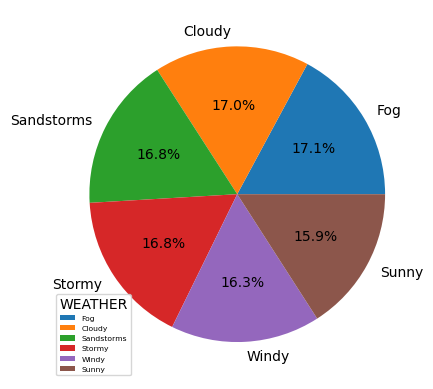

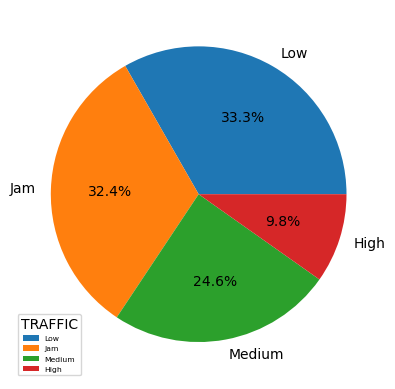

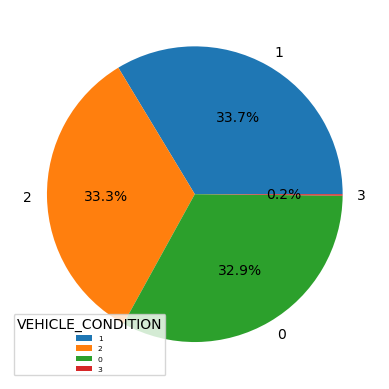

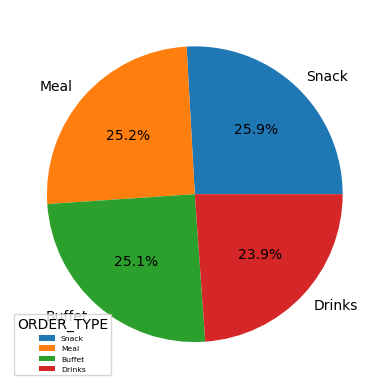

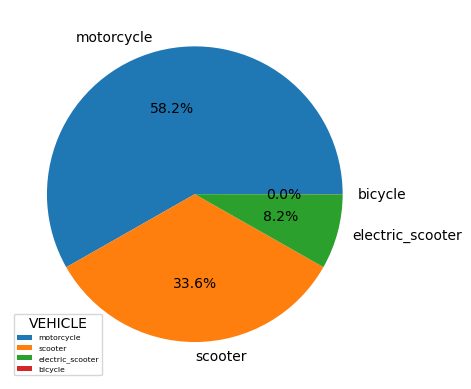

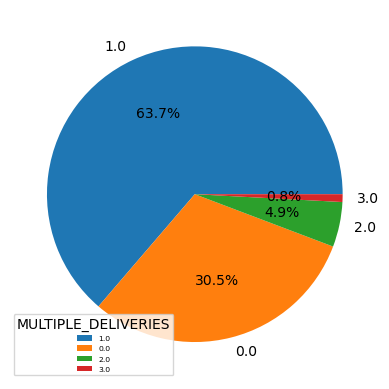

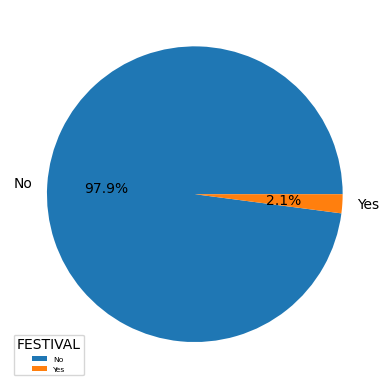

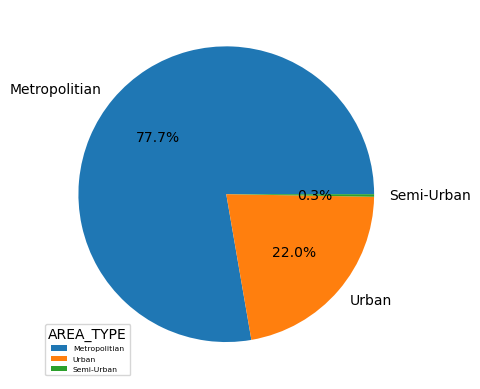

In [370]:
pie_chart(riders_less30[zomato_cats.columns])

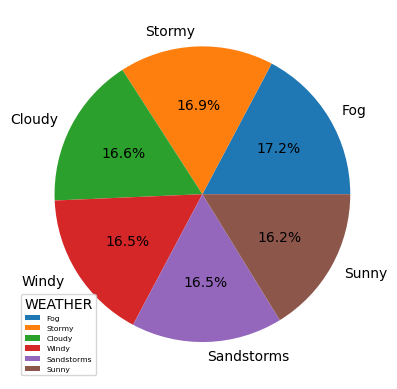

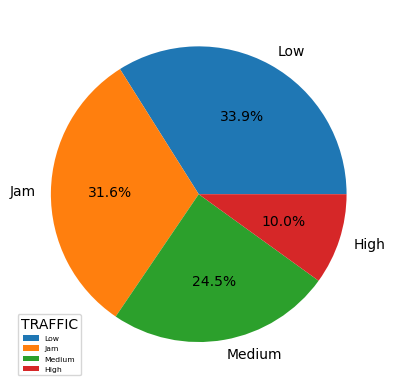

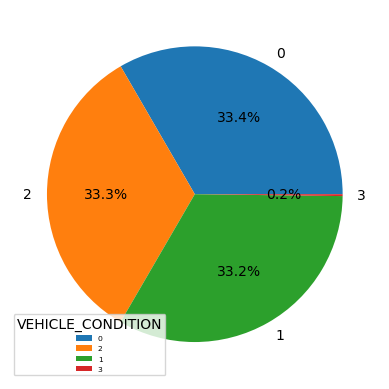

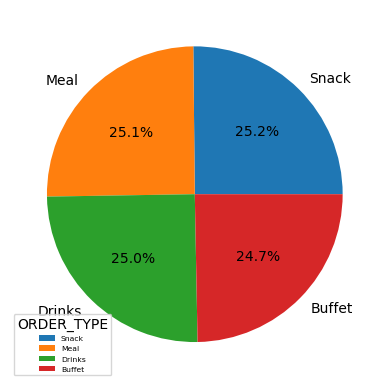

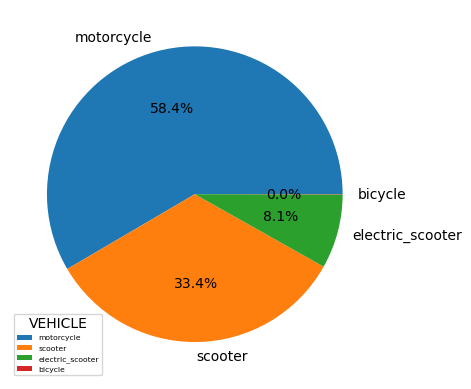

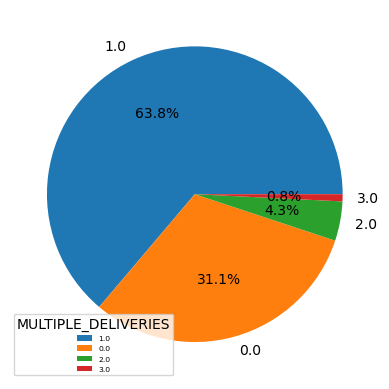

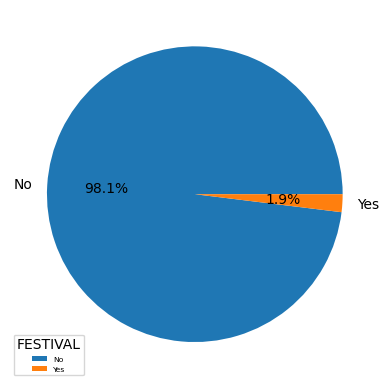

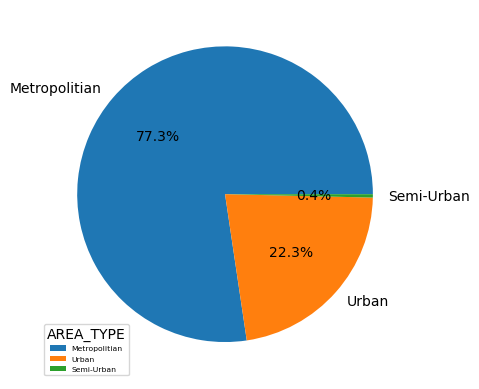

In [372]:
pie_chart(riders_more30[zomato_cats.columns])

#### 4. Number of Orders

##### Monthly Orders

In [90]:
# Count the number of orders by each month 
month_orders = zomato.groupby(sorted(zomato["month"]))["order_id"].count()
month_orders

2     6858
3    30336
4     6047
Name: order_id, dtype: int64

Text(0.5, 1.0, 'Order Count by Month')

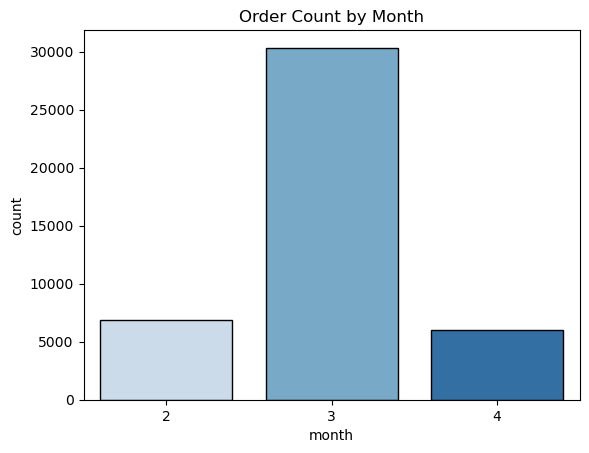

In [376]:
sb.countplot(data = zomato, x = 'month', palette = 'Blues', edgecolor = 'k')
plt.title('Order Count by Month')

##### By Order Date

In [18]:
# Count the number of orders by each date
date_orders = zomato.groupby(sorted(zomato["order_date"]))["order_id"].count()
 # "date is in yyyy-mm-dd"

#sb.scatterplot(date_orders)
date_orders
date_order = list(date_orders.index)


2022-02-11     929
2022-02-12     824
2022-02-13     909
2022-02-14     810
2022-02-15     890
2022-02-16     805
2022-02-17     892
2022-02-18     799
2022-03-01    1069
2022-03-02     958
2022-03-03    1111
2022-03-04     924
2022-03-05    1106
2022-03-06     942
2022-03-07    1086
2022-03-08     910
2022-03-09    1107
2022-03-10     929
2022-03-11    1082
2022-03-12     921
2022-03-13    1114
2022-03-14     921
2022-03-15    1129
2022-03-16     943
2022-03-17    1076
2022-03-18     922
2022-03-19    1095
2022-03-20     932
2022-03-21    1095
2022-03-23     908
2022-03-24    1095
2022-03-25     921
2022-03-26    1115
2022-03-27     921
2022-03-28    1081
2022-03-29     918
2022-03-30    1087
2022-03-31     918
2022-04-01    1090
2022-04-02     934
2022-04-03    1125
2022-04-04     898
2022-04-05    1095
2022-04-06     905
Name: order_id, dtype: int64

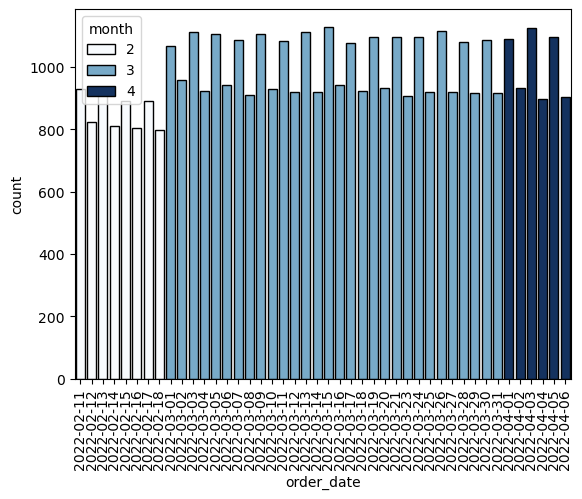

In [22]:
date_order = list(date_orders.index)
sb.countplot(x = "order_date", data = zomato, palette = "Blues",  order = date_order, hue = "month", edgecolor = "k")
plt.xticks(rotation= 90);

##### The number of delivery orders is lower in February and April than in March
##### since the dataset contains a 1-week information only for February and April 

##### The number of delivery orders bounces back and forth by day
##### The number of delivery orders exceeds 100O on March 1st. 

##### Peak FLag: We define peak time orders to be the orders between 18:00 ~ 21:00pm 

##### Delivery Peak Time 

In [299]:
zomato["peak_flag"].value_counts()

peak_flag
0    30983
1    12258
Name: count, dtype: int64

In [301]:
zomato.groupby(zomato["peak_flag"])[["delivery_min", "rider_age", "rider_ratings"]].mean()

,delivery_min,rider_age,rider_ratings
peak_flag,,,
0,24.922119,29.594261,4.641303
1,29.888563,29.486213,4.614562


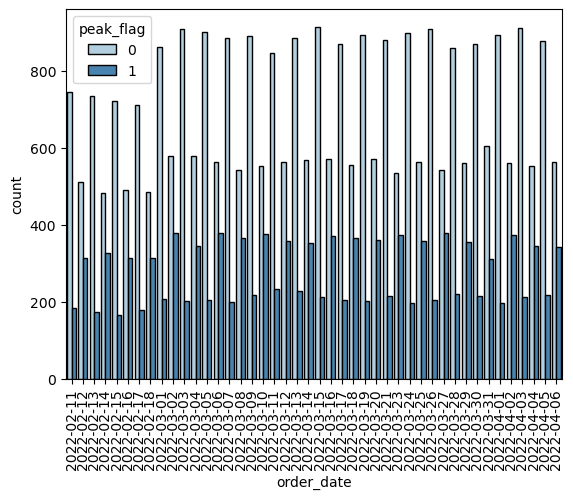

In [297]:
# Number of peak time order by each date 
sb.countplot(x = "order_date", data = zomato, palette = "Blues",  order = date_order, hue = "peak_flag", edgecolor = "k")
plt.xticks(rotation= 90);

In [ ]:
Ratings 3 vs Rating 5 during peak time 


In [303]:
ratings_3["hour"].value_counts()

hour
23.0    52
22.0    47
Name: count, dtype: int64

In [305]:
ratings_5["hour"].value_counts()

hour
23.0    397
17.0    390
21.0    389
19.0    370
18.0    369
20.0    360
22.0    335
8.0     172
11.0    172
10.0    156
9.0     149
15.0     79
16.0     73
12.0     70
14.0     66
13.0     65
Name: count, dtype: int64

In [313]:
# Find another peak time 
zomato["hour"].value_counts()

hour
21.0    4253
17.0    4174
19.0    4150
22.0    4149
23.0    4069
18.0    4058
20.0    4050
8.0     1806
10.0    1767
11.0    1757
9.0     1756
15.0     785
14.0     711
12.0     698
13.0     698
16.0     654
Name: count, dtype: int64

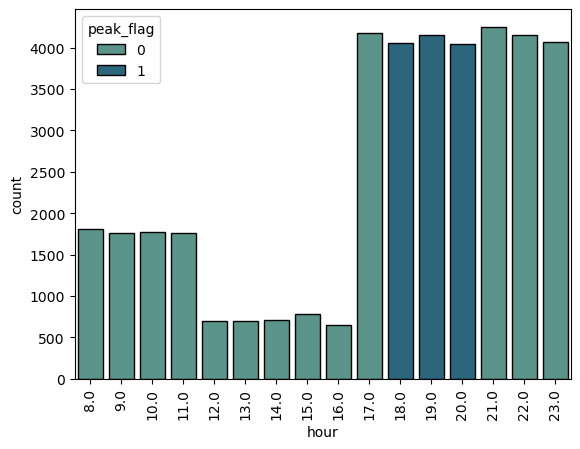

In [323]:
sb.countplot(x = "hour", data= zomato,  palette = 'crest', edgecolor = 'k', hue = "peak_flag")
plt.xticks(rotation = 90);

##### The number of delivery orders begins from 8:00 am to 12:00 am midnight. 
##### The conventionl peak-time of delivery orders are between 18:00 pm and 21:00 pm.
##### The number of delivery orders are consistently at peak from 17:00 pm to midnight. 

#### Delivery Distance 

#### 5. Calculate the distance between restaurants and delivery locations

- We will use logitude and latitude columns in the dataset to get the distance

In [470]:
zomato[["restaurant_latitude", "restaurant_longitude", "delivery_location_latitude", "delivery_location_longitude"]].describe()

,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude
count,43241.000000,43241.000000,43241.000000,43241.000000
mean,17.217144,70.679435,17.458547,70.830459
std,7.746992,21.429737,7.340103,21.139008
min,-30.902872,-88.366217,0.010000,0.010000
25%,12.933298,73.170283,12.985996,73.280283
50%,18.551440,75.898497,18.633481,76.002574
75%,22.732225,78.045359,22.785049,78.104222
max,30.914057,88.433452,31.054057,88.563452


In [21]:
!pip install geopy

  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)


In [472]:
# Use geopy package to calculate the distance 
from geopy.distance import geodesic

In [474]:
delivery_loc = zip(zomato["delivery_location_latitude"], zomato['delivery_location_longitude'])
delivery_loc = list(delivery_loc)
print(delivery_loc[0])

(30.397968, 78.116106)


In [476]:
restaurant_loc = zip(zomato["restaurant_latitude"], zomato['restaurant_longitude'])
restaurant_loc = list(restaurant_loc)
print(restaurant_loc[0])

(30.327968, 78.046106)


In [478]:
i = 0
distance_km = []
distance_mi = []
for i in range(len(zomato)):
    distance_km.append(geodesic(restaurant_loc[i],delivery_loc[i]).km)
    distance_mi.append(geodesic(restaurant_loc[i],delivery_loc[i]).miles)

In [479]:
print(distance_km[:5])
print(distance_mi[:5])

[10.27146402322994, 6.229376076976667, 13.764305929575334, 2.9277947281095997, 19.37348408863585]
[6.382391846137271, 3.8707548398457177, 8.55274318577963, 1.819247300831643, 12.038124905946676]


In [484]:
zomato["delivery_distance_km"] = distance_km 
zomato["delivery_distance_mi"] = distance_mi

print(zomato["delivery_distance_km"].describe())
print(zomato["delivery_distance_mi"].describe())

count    43241.000000
mean        36.919818
std        514.256998
min          1.463837
25%          4.654040
50%          9.204057
75%         13.660855
max      19709.575543
Name: delivery_distance_km, dtype: float64
count    43241.000000
mean        22.940912
std        319.544484
min          0.909586
25%          2.891886
50%          5.719136
75%          8.488462
max      12246.962454
Name: delivery_distance_mi, dtype: float64


{'whiskers': [<matplotlib.lines.Line2D at 0x173f2396ab0>,
 'caps': [<matplotlib.lines.Line2D at 0x173f2397890>,
 'boxes': [<matplotlib.lines.Line2D at 0x173f24c8b00>],
 'medians': [<matplotlib.lines.Line2D at 0x173f2395310>],
 'fliers': [<matplotlib.lines.Line2D at 0x173f23953d0>],
 'means': []}

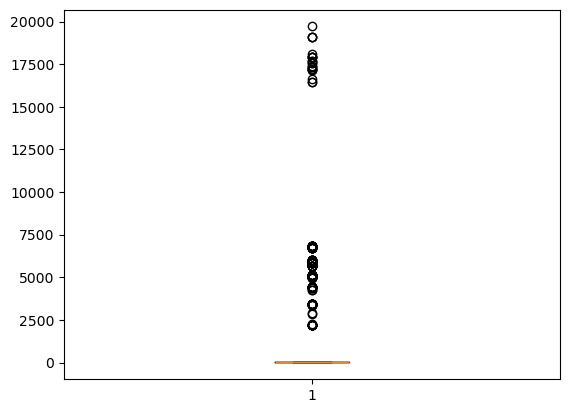

In [486]:
plt.boxplot(x = "delivery_distance_km", data = zomato)

In [488]:
zomato[zomato["delivery_distance_km"] > 1000]

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,hour,peak_flag,delivery_distance_km,delivery_distance_mi
81,0xc042,AGRRES010DEL01,34.0,4.7,-27.163303,78.057044,27.233303,78.127044,2022-02-16,NaN,...,0.0,No,Metropolitian,15,-153722867280912928,2,NaN,0,6019.211231,3740.164459
264,0xc044,AGRRES12DEL03,32.0,4.7,-27.165108,78.015053,27.225108,78.075053,2022-02-13,1900-01-01 20:55:00,...,1.0,No,Metropolitian,31,15,2,20.0,1,6018.501935,3739.723723
1026,0xc086,GOARES010DEL03,20.0,4.7,-15.546594,73.760431,15.606594,73.820431,2022-02-13,NaN,...,1.0,No,Metropolitian,29,-153722867280912928,2,NaN,0,3445.587513,2140.988821
1677,0xc067,BHPRES13DEL02,39.0,4.5,-23.230791,77.437020,23.250791,77.457020,2022-02-13,1900-01-01 09:15:00,...,1.0,No,Metropolitian,29,5,2,9.0,0,5142.408748,3195.344655
1863,0xc061,KOLRES16DEL01,25.0,4.0,-22.539129,88.365507,22.549129,88.375507,2022-02-15,1900-01-01 09:25:00,...,0.0,No,Metropolitian,19,5,2,9.0,0,4988.108200,3099.466740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41590,0xc0b9,GOARES16DEL01,32.0,4.6,-15.498603,73.826911,15.568603,73.896911,2022-02-18,1900-01-01 23:10:00,...,1.0,No,Metropolitian,24,5,2,23.0,0,3436.075555,2135.078364
41770,0xc06d,GOARES14DEL03,22.0,5.0,-15.157944,73.950889,15.217944,74.010889,2022-02-17,1900-01-01 18:50:00,...,1.0,No,Metropolitian,27,5,2,18.0,1,3359.577533,2087.544697
42337,0xc094,KOCRES06DEL03,23.0,4.8,-9.982834,76.283268,10.072834,76.373268,2022-02-14,1900-01-01 19:20:00,...,1.0,No,Metropolitian,21,15,2,19.0,1,2217.889397,1378.132579
42613,0xc0c2,AURGRES03DEL03,30.0,4.9,-19.874733,75.353942,19.904733,75.383942,2022-02-15,1900-01-01 22:20:00,...,0.0,No,Metropolitian,15,15,2,22.0,0,4400.319819,2734.231972


In [490]:
# The unrealistic delivery travel distance
zomato_distance_km = zomato[zomato["delivery_distance_km"] < 1000]

In [506]:
len(zomato_distance_km)

43062

In [492]:
zomato_distance_km["delivery_distance_km"].describe()

count    43062.000000
mean         9.697256
std          5.600280
min          1.463837
25%          4.649061
50%          9.203411
75%         13.660007
max         20.942906
Name: delivery_distance_km, dtype: float64

<Axes: xlabel='delivery_distance_km'>

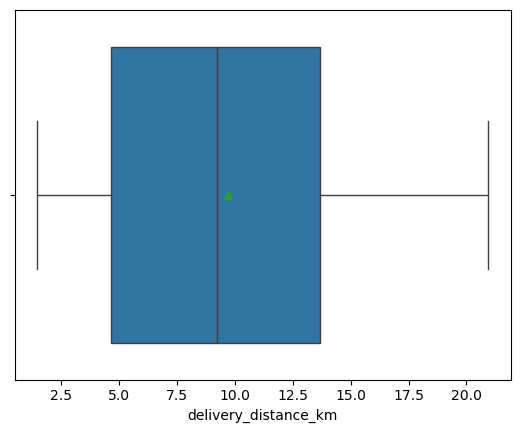

In [502]:
sb.boxplot(x = zomato_distance_km["delivery_distance_km"], orient = "h", showmeans = True)

<Axes: xlabel='delivery_distance_km', ylabel='Count'>

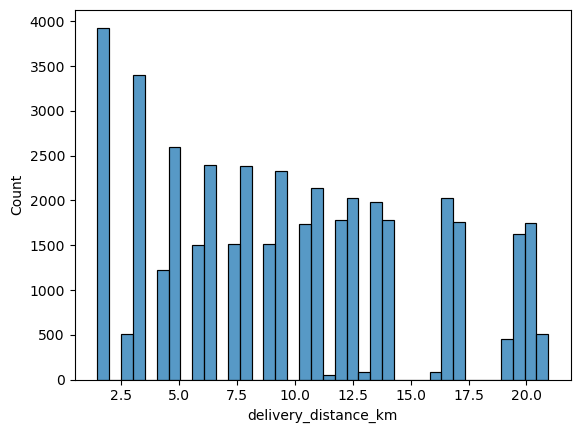

In [610]:
sb.histplot(x = "delivery_distance_km", data = zomato_distance)

<Axes: xlabel='delivery_min', ylabel='delivery_distance_km'>

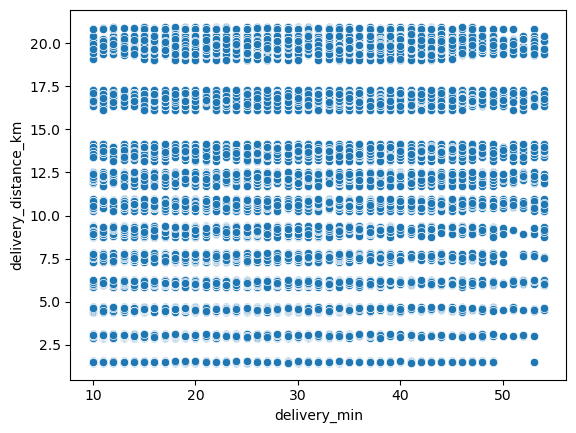

In [514]:
# Delivery time vs. Delivery distance
sb.scatterplot(x = "delivery_min", y = "delivery_distance_km", data= zomato_distance_km)

In [608]:
zomato[["delivery_min", "delivery_distance_km"]].corr()

,delivery_min,delivery_distance_km
delivery_min,1.000000,0.324318
delivery_distance_km,0.324318,1.000000


In [614]:
# Average Delivery Distance by distinct riders 
zomato.groupby("rider_id")["delivery_distance_km"].mean()

rider_id
AGRRES010DEL01     8.175253
AGRRES010DEL02     9.130756
AGRRES010DEL03    11.662185
AGRRES01DEL01      9.909364
AGRRES01DEL02     11.147774
                    ...    
VADRES19DEL02     11.037304
VADRES19DEL03      9.074325
VADRES20DEL01      8.696067
VADRES20DEL02     10.649286
VADRES20DEL03      8.807453
Name: delivery_distance_km, Length: 1320, dtype: float64

In [620]:
zomato.groupby("rider_id")["delivery_distance_km"].mean().describe()

count    1320.000000
mean        9.734261
std         1.278761
min         6.233549
25%         8.846742
50%         9.428074
75%        10.610595
max        15.292005
Name: delivery_distance_km, dtype: float64

Text(0.5, 1.0, 'Average Delivery Distance by Riders')

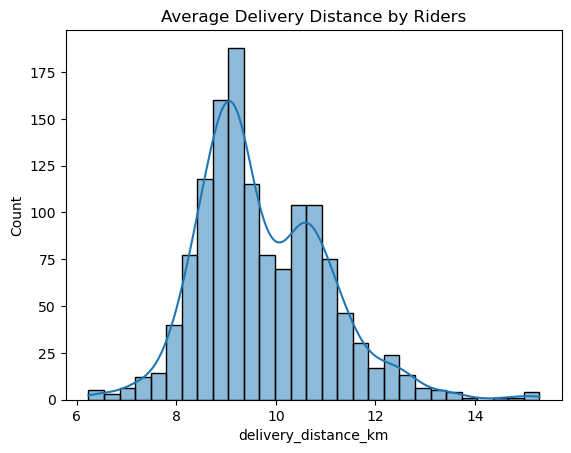

In [616]:
sb.histplot(zomato.groupby(zomato["rider_id"])["delivery_distance_km"].mean(), kde  = True)

plt.title("Average Delivery Distance by Riders")

In [ ]:
# The distribution of average delivery distance by a rider shows that 
# the number of riders are between delivery distances less than or greater than 10km 

##### Delivery Distance by area_type, vehicle_type

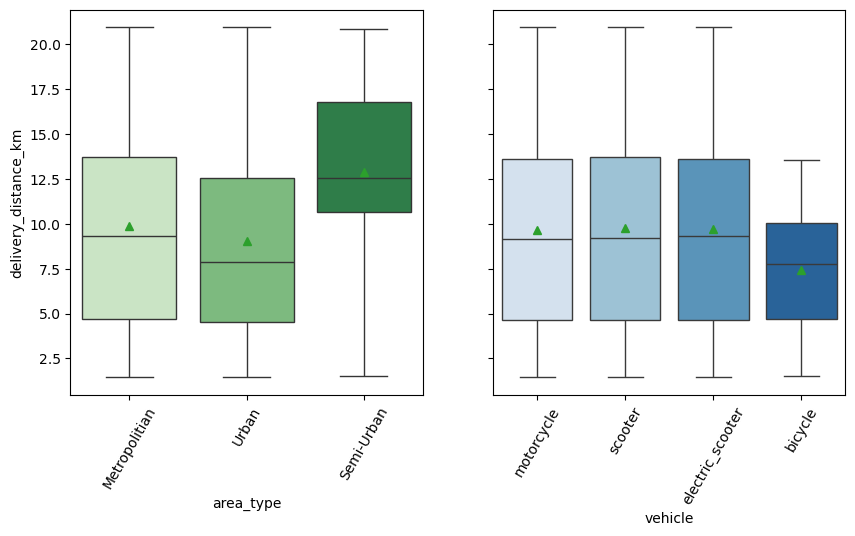

In [630]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1, figsize = (10, 5), sharey = True)

sb.boxplot(x = "area_type", y = "delivery_distance_km", ax= ax1, data = zomato_distance, palette =  "Greens", showmeans = True)
sb.boxplot(x = "vehicle", y = "delivery_distance_km", ax= ax2, data = zomato_distance, palette =  "Blues", showmeans = True)

for ax in [ax1, ax2]:
    for tick in ax.get_xticklabels():
        tick.set_rotation(60);

<Axes: xlabel='delivery_min', ylabel='delivery_distance_km'>

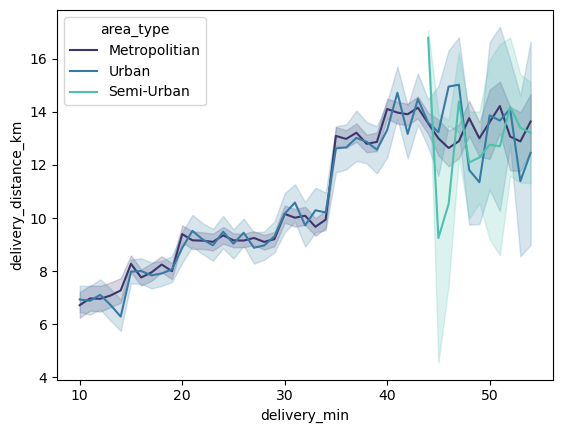

In [641]:
sb.lineplot(data = zomato_distance, x = 'delivery_min', y = 'delivery_distance_km',
             hue = "area_type", palette = 'mako')

In [528]:
zomato_distance_km[zomato_distance_km["rider_age"] == 15]["delivery_distance_km"].describe()

count    25.000000
mean      9.993848
std       4.977545
min       1.488108
25%       7.589527
50%       9.295205
75%      12.235733
max      20.212364
Name: delivery_distance_km, dtype: float64

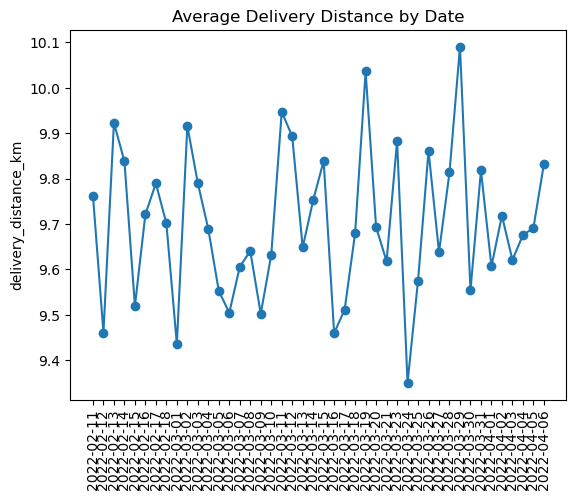

In [674]:
# Average delivery distance by each date 

date_distance= zomato.groupby(sorted(zomato["order_date"]))["delivery_distance_km"].mean()
date_distance
plt.scatter(x = date_distance.index, y = date_distance)
sb.lineplot(data = date_distance)
plt.title("Average Delivery Distance by Date")
plt.xticks(rotation = 90);

In [ ]:
#배차시간 Complete Case Analysis

#### Time_to_pick 
#### Need to drop rows with unrealistic values 

In [654]:
zomato["time_to_pick"].value_counts()

time_to_pick
 5                     11891
 10                    11654
 15                    11526
-153722867280912928     7991
Name: count, dtype: int64

In [ ]:
# Drop rows where time to pick the order is the value calculated from NA's
zomato.drop(zomato[zomato.time_to_pick == -153722867280912928].index, inplace = True)


In [650]:
zomato_timepick = zomato[zomato["time_to_pick"] != -153722867280912928]
zomato_timepick

,order_id,rider_id,rider_age,rider_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_ordered,...,order_type,vehicle,multiple_deliveries,festival,area_type,delivery_min,time_to_pick,month,delivery_distance_km,delivery_distance_mi
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,1900-01-01 21:55:00,...,Snack,motorcycle,3.0,No,Metropolitian,46,15,2,10.271464,6.382392
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,1900-01-01 14:55:00,...,Meal,motorcycle,1.0,No,Metropolitian,23,10,2,6.229376,3.870755
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,1900-01-01 17:30:00,...,Drinks,scooter,1.0,No,Metropolitian,21,10,3,13.764306,8.552743
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,1900-01-01 09:20:00,...,Buffet,motorcycle,0.0,No,Metropolitian,20,10,2,2.927795,1.819247
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,1900-01-01 19:50:00,...,Snack,scooter,1.0,No,Metropolitian,41,15,2,19.373484,12.038125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43235,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,1900-01-01 21:45:00,...,Drinks,motorcycle,1.0,No,Metropolitian,33,10,3,16.576800,10.300346
43236,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,1900-01-01 11:35:00,...,Meal,motorcycle,0.0,No,Metropolitian,32,10,3,1.488112,0.924670
43237,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,1900-01-01 19:55:00,...,Buffet,motorcycle,1.0,No,Metropolitian,36,15,2,10.983242,6.824670
43239,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,1900-01-01 13:35:00,...,Snack,motorcycle,1.0,No,Metropolitian,26,5,3,6.219668,3.864722


In [658]:
zomato_timepick["time_to_pick"].value_counts()

time_to_pick
5     11891
10    11654
15    11526
Name: count, dtype: int64

In [ ]:
# We see that the riders' time to pick up the order is 5, 10, or 15 minutes
sb.histplot(zomato["time_to_pick"])

In [ ]:
#### Order date and time_to_pick

In [ ]:
date_timepick = zomato.groupby(sorted(zomato["order_date"]))["time_to_pick"].mean()

plt.scatter(x = date_timepick.index, y= date_timepick)

sb.lineplot(data = date_timepick)
plt.xticks(rotation = 90);